In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from pathlib import Path
import pandas as pd
import json
from src.config import CHECKPOINT_DIR, DEFAULT_TRAINING_PARAMS_V2, DEFAULT_TRAINING_PARAMS_V3
from pathlib import Path
import matplotlib.pyplot as plt



In [2]:
experiment_root = CHECKPOINT_DIR / "CNN_LSTM_V3" / "grid_search_5_unfreeze_from_15"

In [2]:
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "grid_search_2"

In [3]:
grid_search_results_path = experiment_root / "grid_search_results.csv"

df = pd.read_csv(grid_search_results_path)
df = df.sort_values("best_val_acc", ascending=False)
df.head(50)

,run_name,seed,max_people,batch_size,epochs,learning_rate,min_lr,scheduler_patience,factor,early_stopping_patience,...,adjacency_normalisation_mode,temporal_kernel_size,dropout,edge_importance_weighting,best_val_acc,final_train_acc,final_val_acc,final_train_loss,final_val_loss,epochs_ran
57,people3_lr20_d03,42,3,4,80,0.00020,0.000010,5,0.5,15,...,column,9,0.3,True,0.7975,0.968125,0.7725,0.108884,1.066824,45
52,people3_d04,42,3,4,80,0.00020,0.000010,5,0.5,15,...,column,9,0.4,True,0.7975,0.953125,0.7575,0.153209,0.942672,36
51,people3_d03,42,3,4,80,0.00020,0.000010,5,0.5,15,...,column,9,0.3,True,0.7975,0.968125,0.7725,0.108884,1.066824,45
58,people3_lr20_d04,42,3,4,80,0.00020,0.000010,5,0.5,15,...,column,9,0.4,True,0.7975,0.953125,0.7575,0.153209,0.942672,36
61,people3_candidate2,42,3,4,80,0.00020,0.000001,3,0.5,15,...,column,9,0.3,True,0.7925,0.924375,0.7700,0.224294,0.787818,47
39,cand2,42,2,4,80,0.00020,0.000010,5,0.5,15,...,column,9,0.4,True,0.7825,0.967500,0.7450,0.109446,0.937086,41
56,people3_wd2,42,3,4,80,0.00020,0.000010,5,0.5,15,...,column,9,0.5,True,0.7825,0.922500,0.7750,0.205699,0.858110,29
50,people3_default,42,3,4,80,0.00020,0.000010,5,0.5,15,...,column,9,0.5,True,0.7825,0.960000,0.7650,0.123282,1.335675,40
4,lr_3e4,42,2,4,80,0.00030,0.000010,5,0.5,15,...,column,9,0.5,True,0.7825,0.909375,0.7600,0.245977,0.658414,35
29,lr20_d04,42,2,4,80,0.00020,0.000010,5,0.5,15,...,column,9,0.4,True,0.7825,0.967500,0.7450,0.109446,0.937086,41


In [4]:
def make_title(run_name, config, default_config=DEFAULT_TRAINING_PARAMS_V3):
    title = [run_name]

    for param in config:
        if param in default_config and config[param] != default_config[param]:
            title.append(f"{param}={config[param]}")

    return " | ".join(title)

def get_results(results_path):

    checkpoint_path = results_path / "best_model.pt"
    history_path = results_path / "history.csv"
    summary_path = results_path / "summary.csv"
    config_path = results_path / "config.json"

    required_files = [
        checkpoint_path,
        history_path,
        summary_path,
        config_path,
    ]

    if not all(path.exists() for path in required_files):
        return None

    checkpoint = torch.load(
        checkpoint_path,
        map_location=torch.device("cpu")
    )

    history = pd.read_csv(history_path)
    summary = pd.read_csv(summary_path)

    with config_path.open("r", encoding="utf-8") as f:
        config = json.load(f)

    return checkpoint, history, summary, config

def plot_grid_search_results(experiment_root):

    run_dirs = sorted([d for d in experiment_root.iterdir() if d.is_dir()])
    
    for run_dir in run_dirs:

        results = get_results(run_dir)

        if results is None:
            print(f"Skipping incomplete run: {run_dir.name}")
            continue

        checkpoint, history, summary, config = results

        epochs = range(1, len(history["train_loss"]) + 1)

        title = make_title(run_dir.name, config)

        plt.figure(figsize=(12, 5))

        # Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, history["train_loss"], label="Train Loss")
        plt.plot(epochs, history["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss")
        plt.legend()
        plt.grid(True)

        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, history["train_acc"], label="Train Acc")
        plt.plot(epochs, history["val_acc"], label="Val Acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy")
        plt.legend()
        plt.grid(True)

        plt.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.show()

        print(summary['best_val_acc'][0])
        print(config)

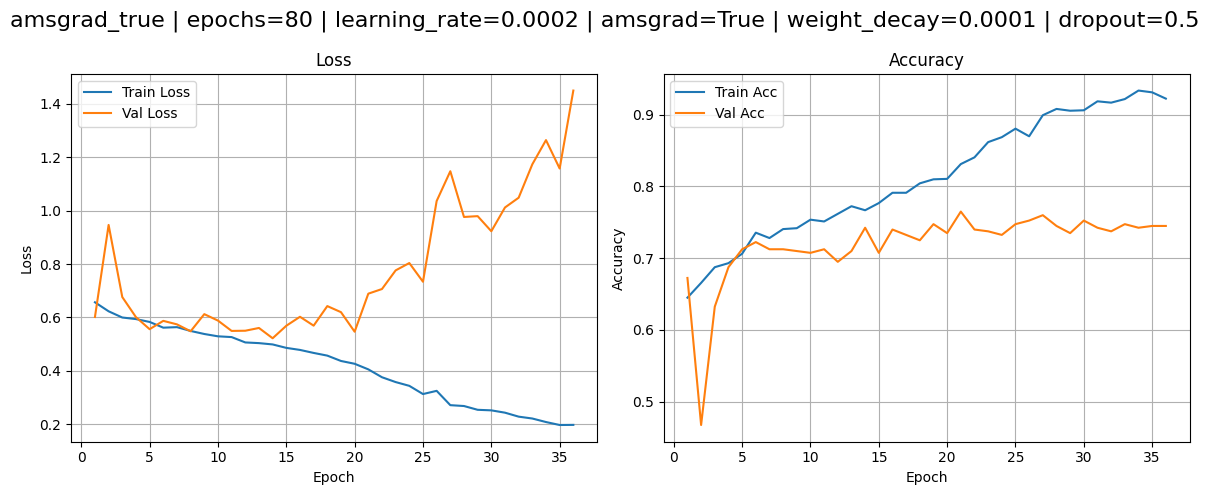

0.765
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': True, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


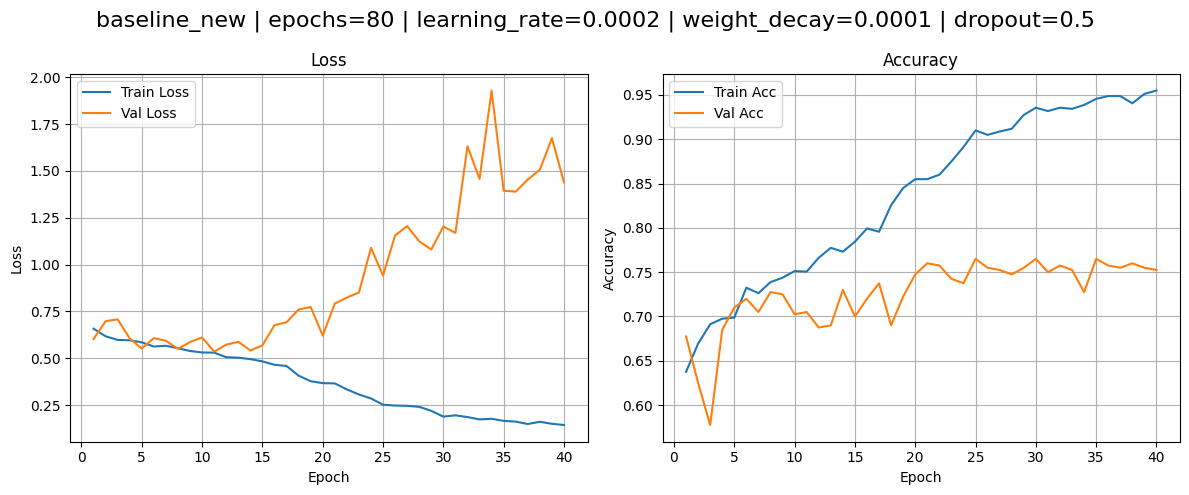

0.765
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


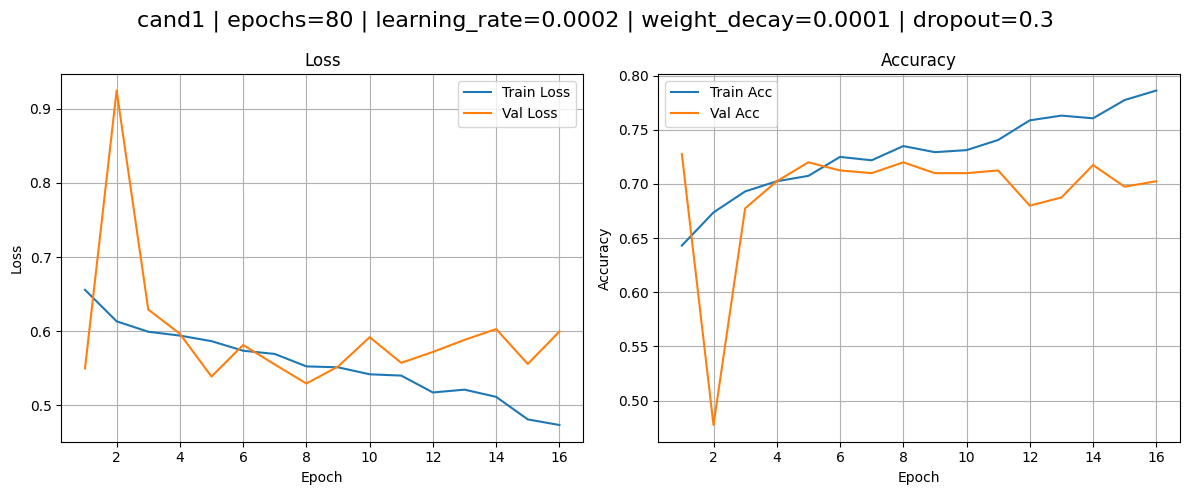

0.7275
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


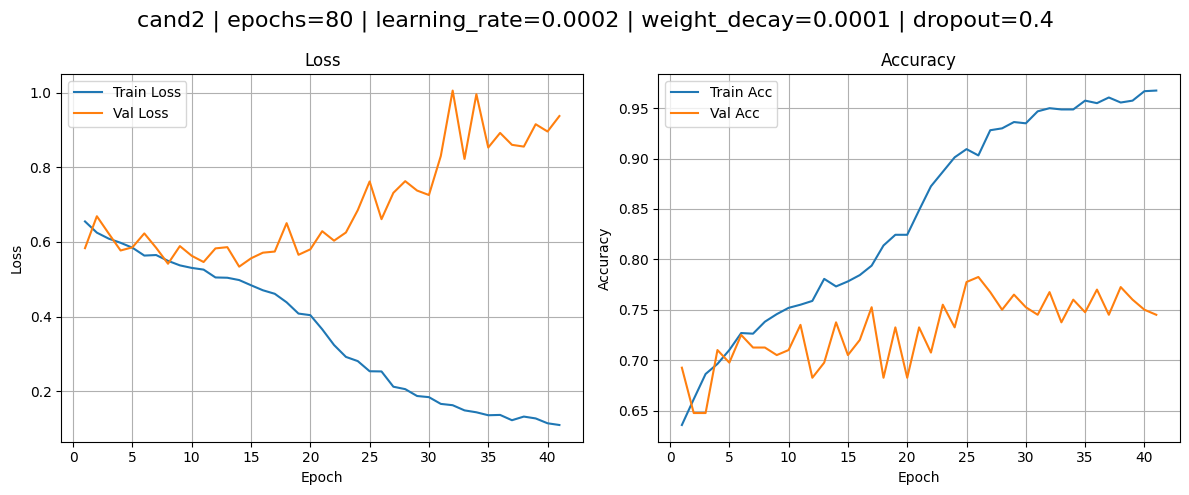

0.7825
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


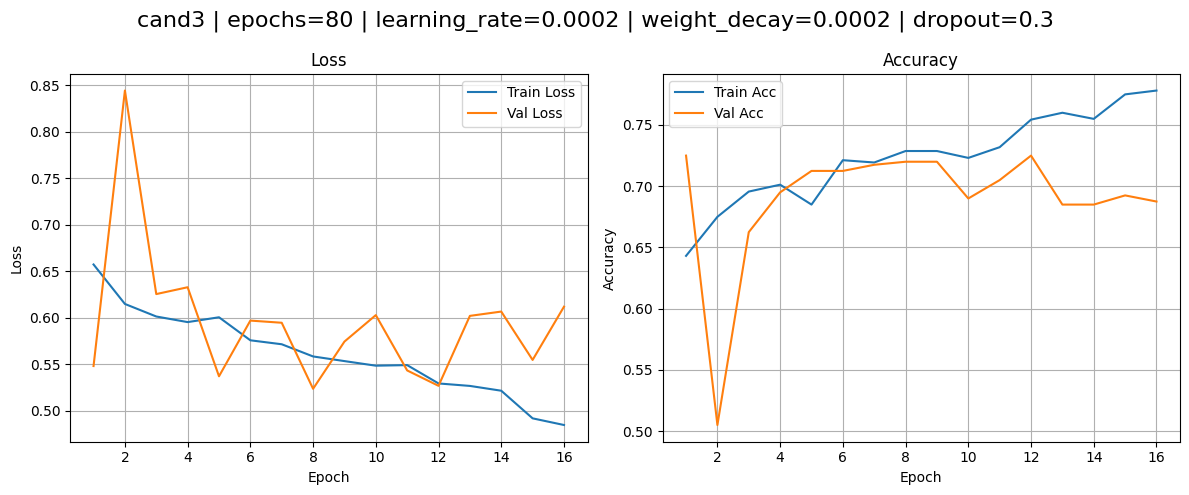

0.725
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0002, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


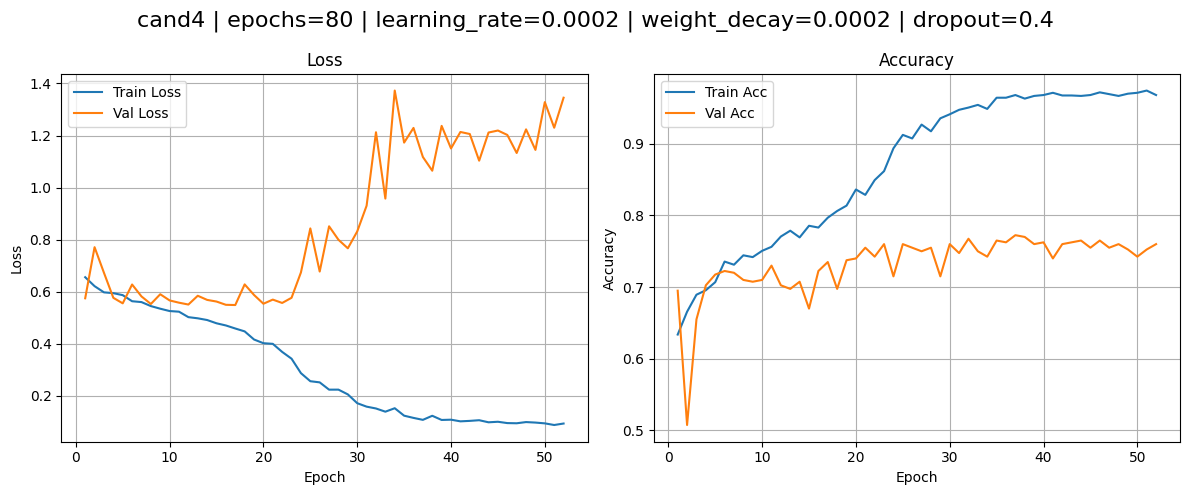

0.7725
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0002, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


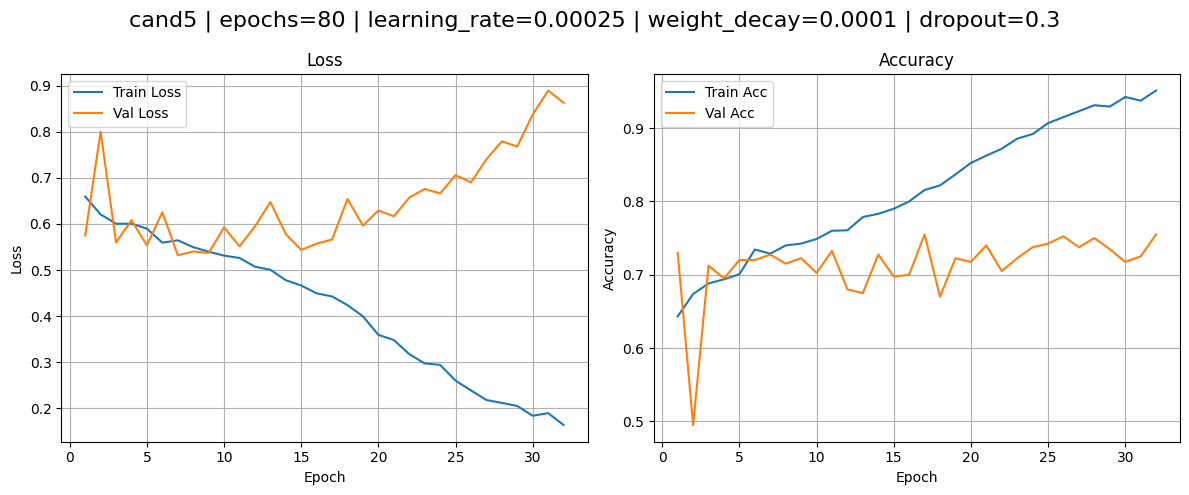

0.755
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00025, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


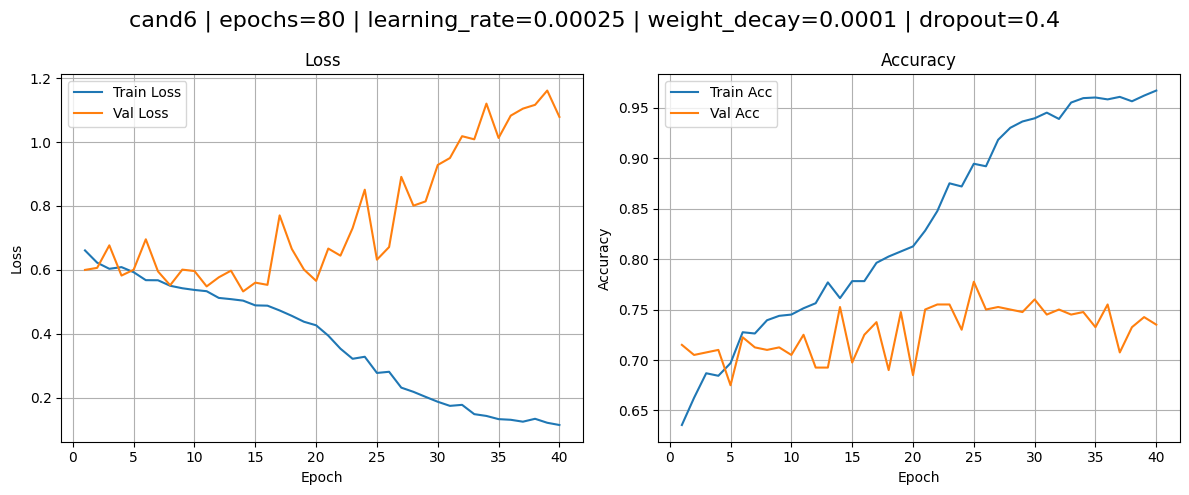

0.7775
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00025, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


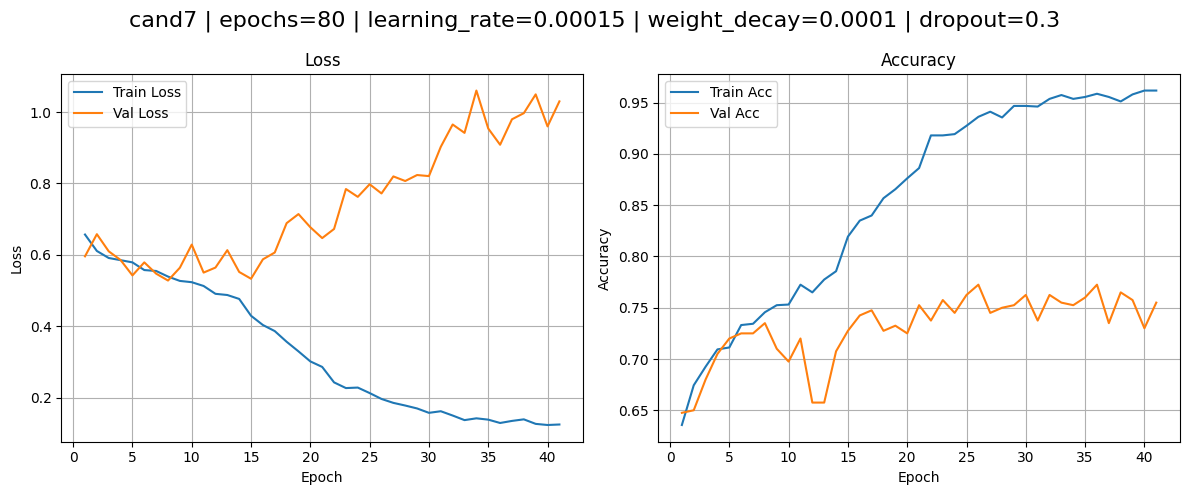

0.7725
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00015, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


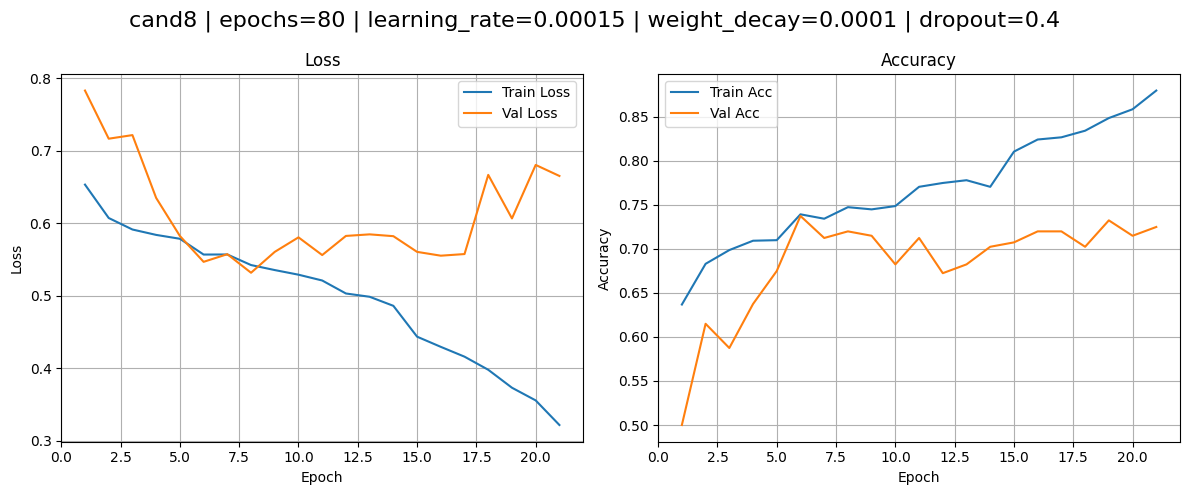

0.7375
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00015, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


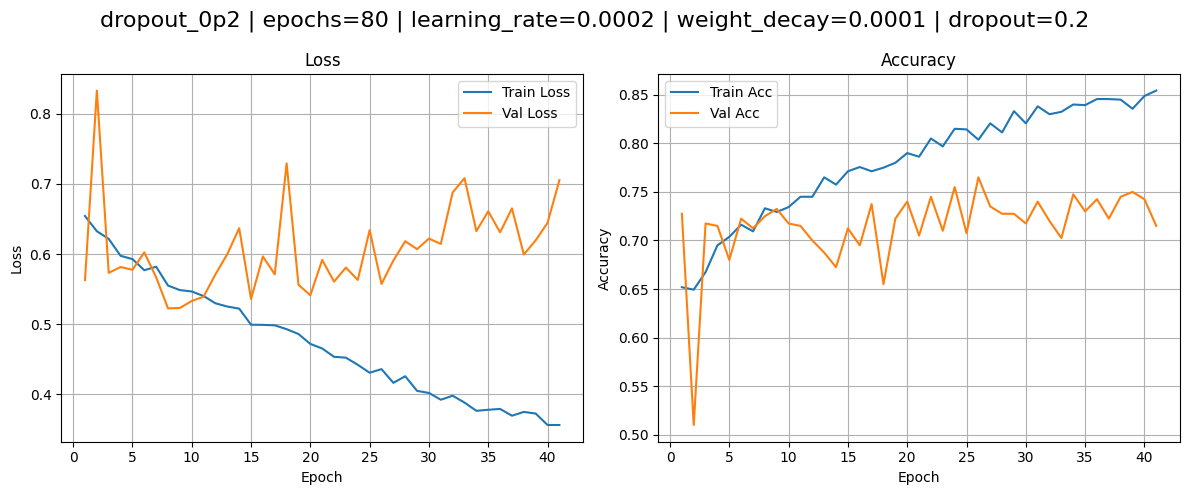

0.765
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.2, 'edge_importance_weighting': True}


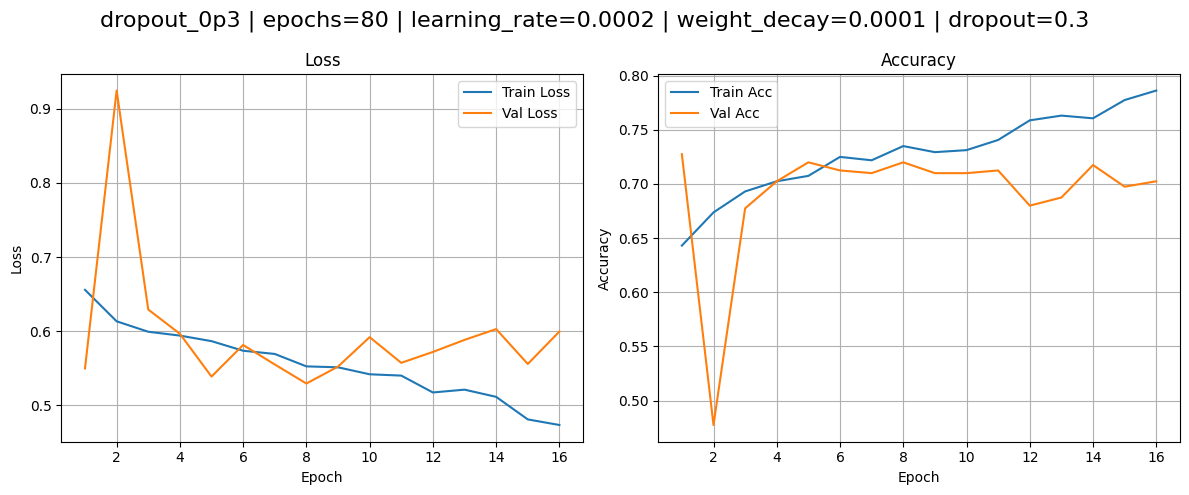

0.7275
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


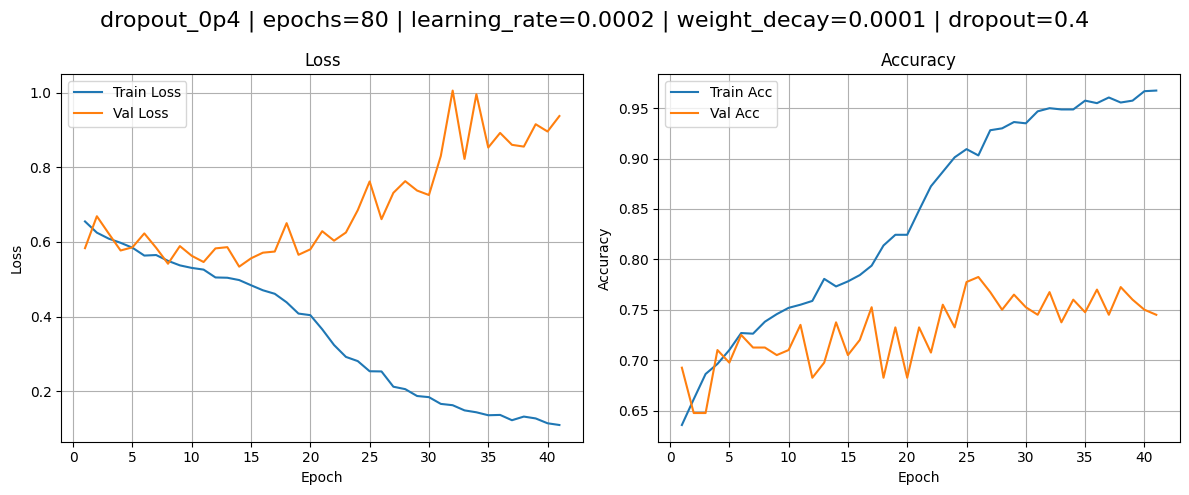

0.7825
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


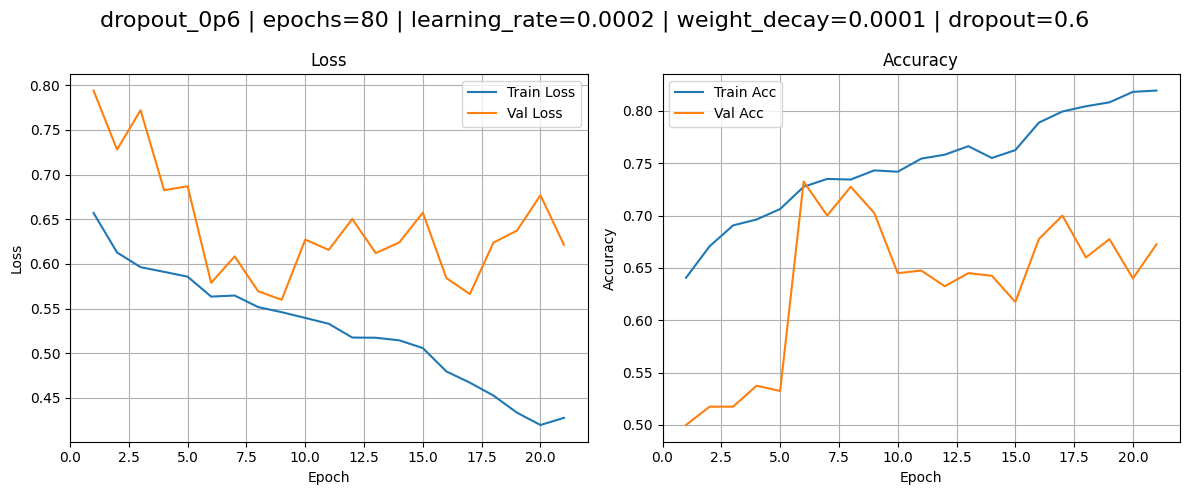

0.7325
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.6, 'edge_importance_weighting': True}


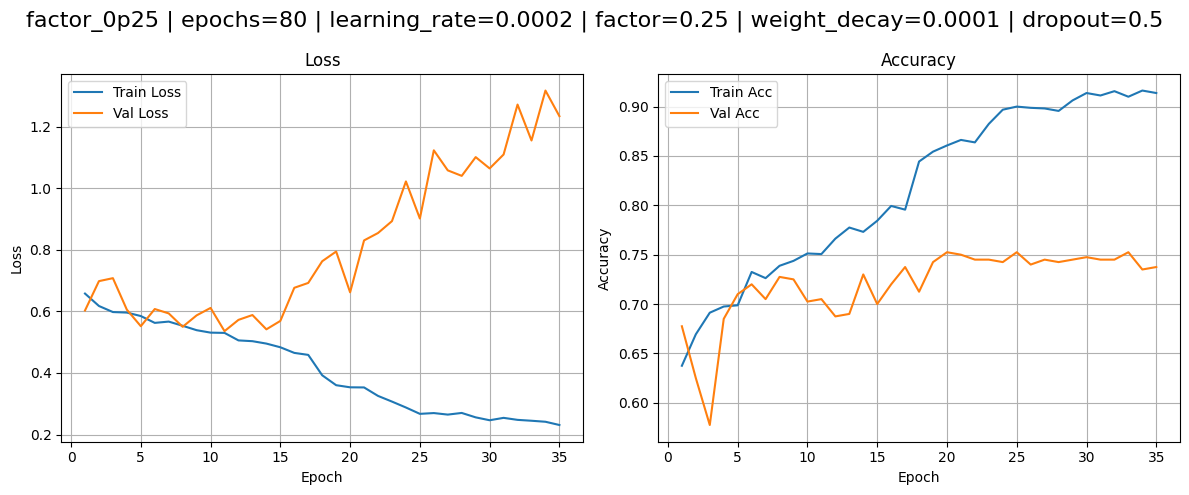

0.7525
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.25, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


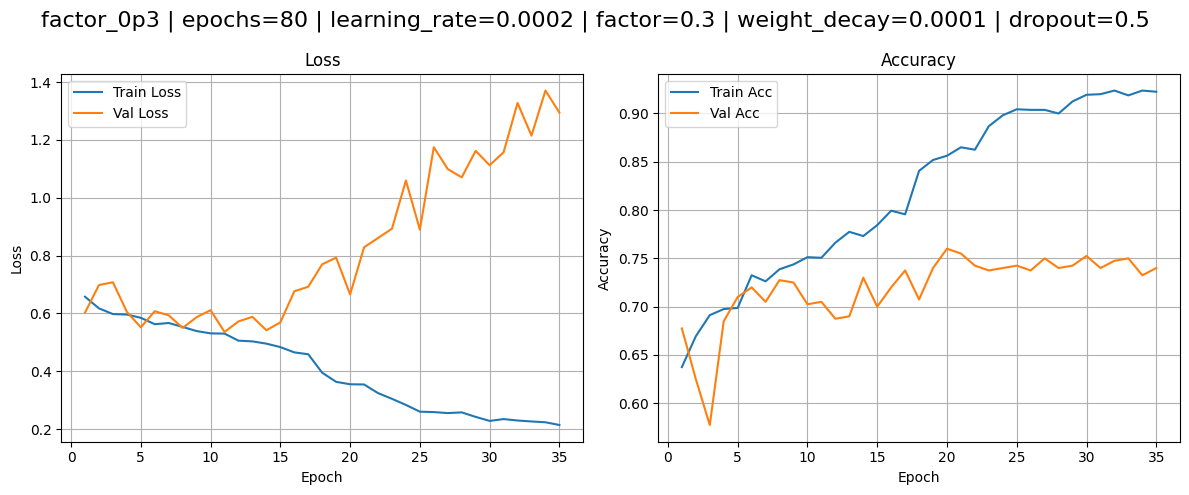

0.76
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.3, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


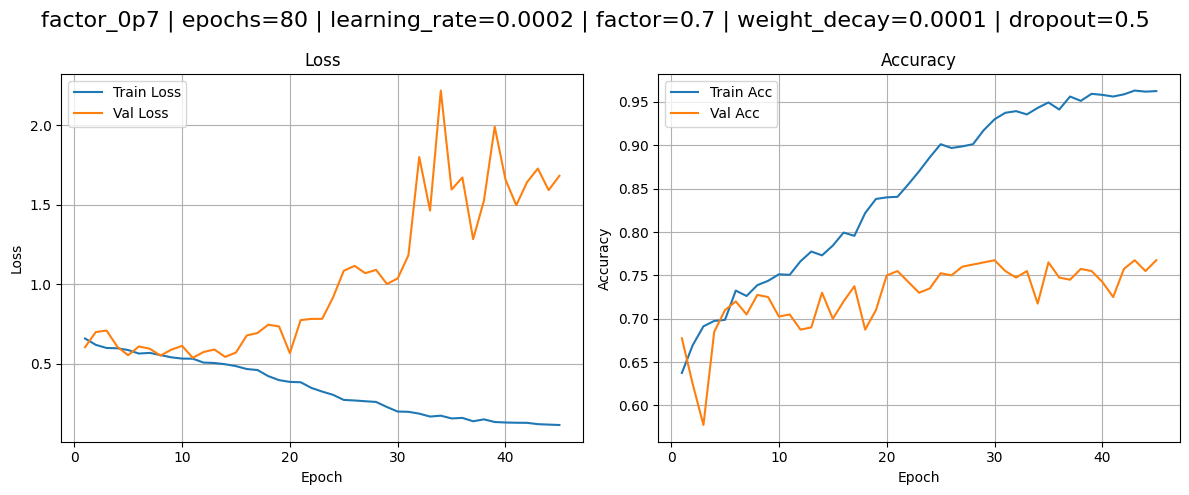

0.7675
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.7, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


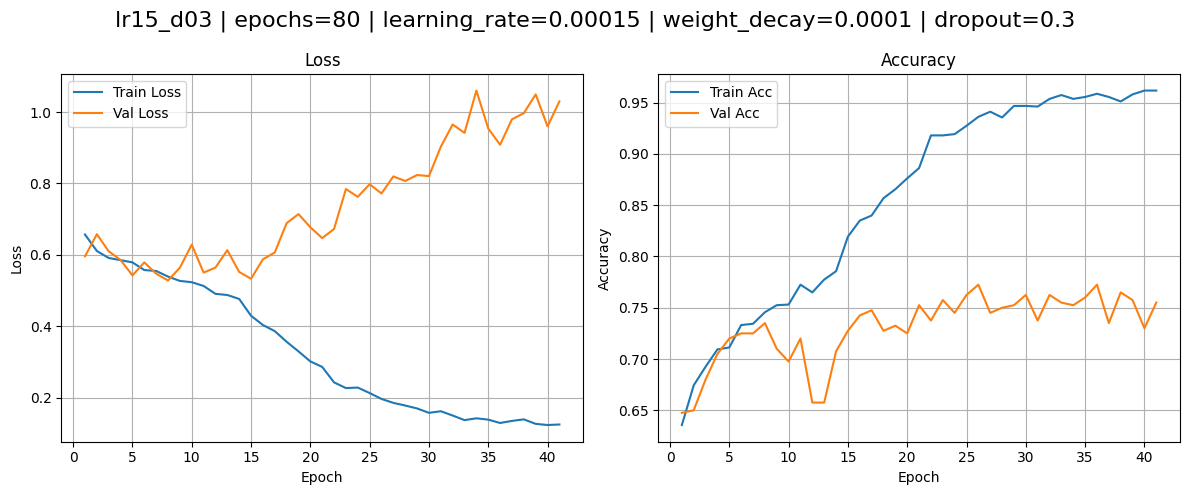

0.7725
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00015, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


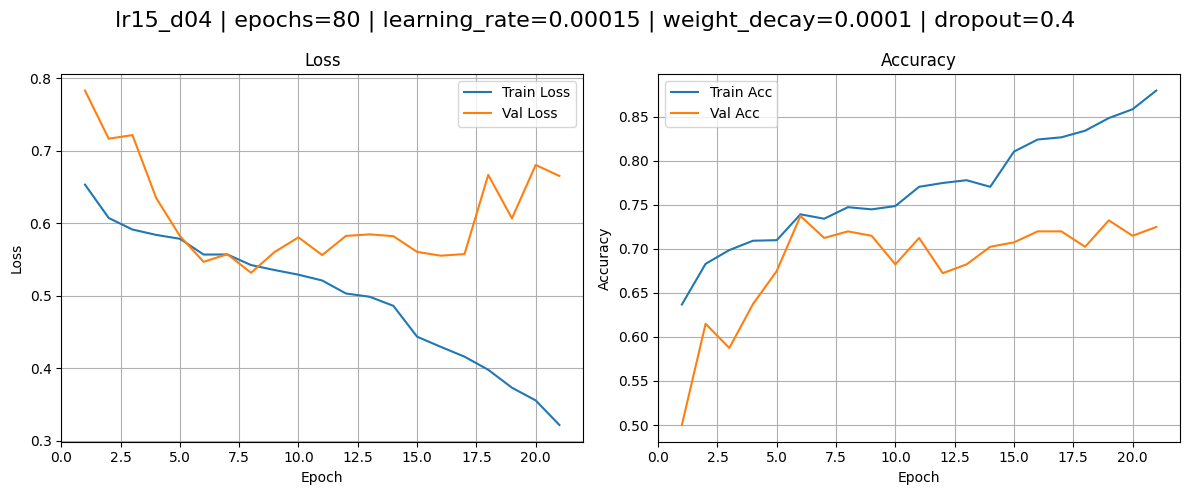

0.7375
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00015, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


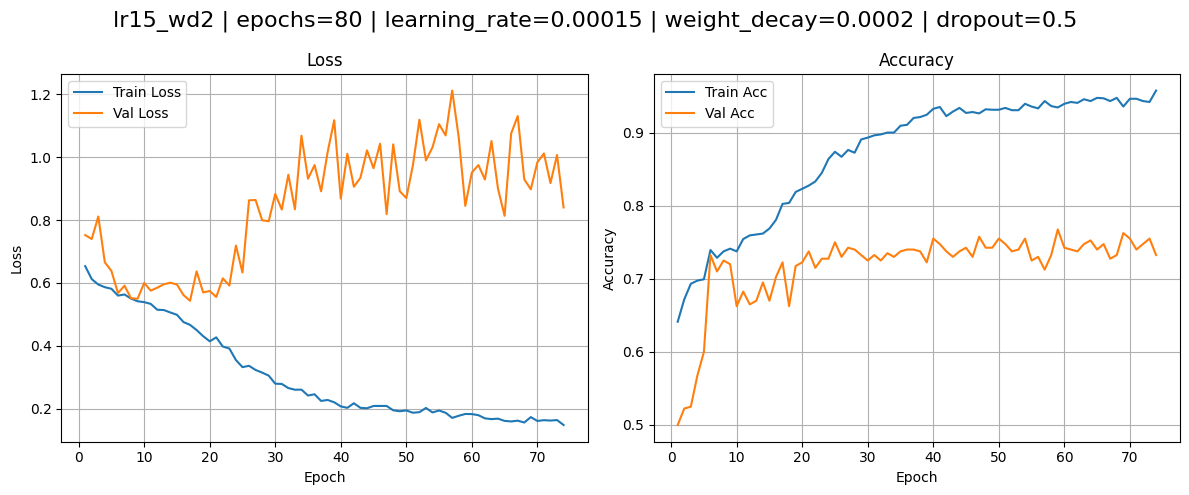

0.7675
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00015, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0002, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


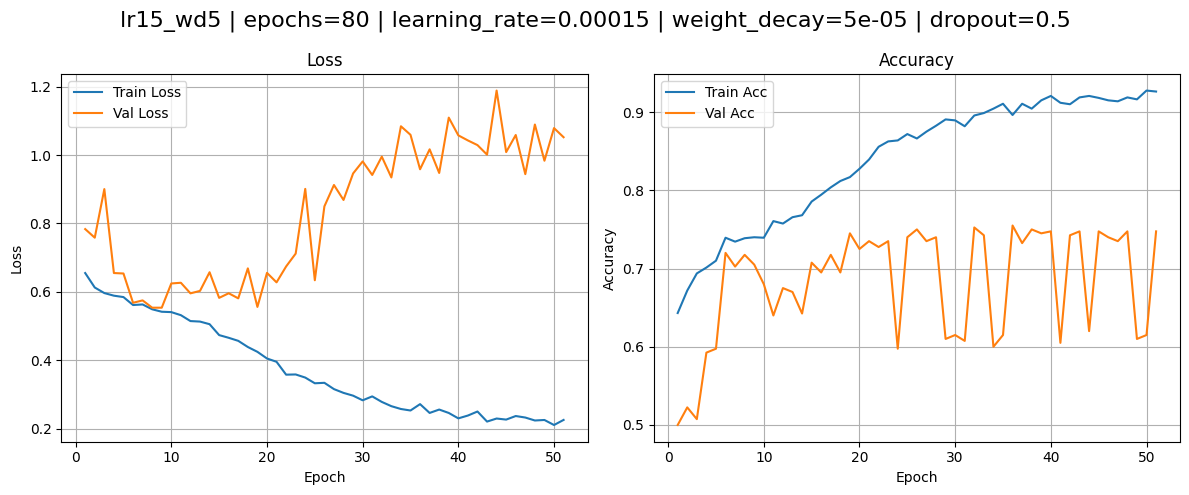

0.755
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00015, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 5e-05, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


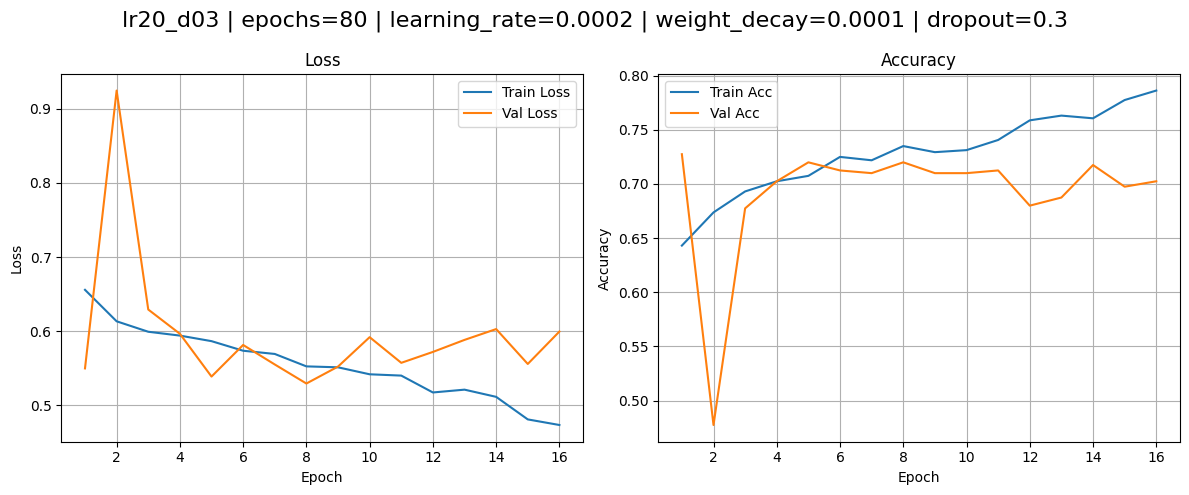

0.7275
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


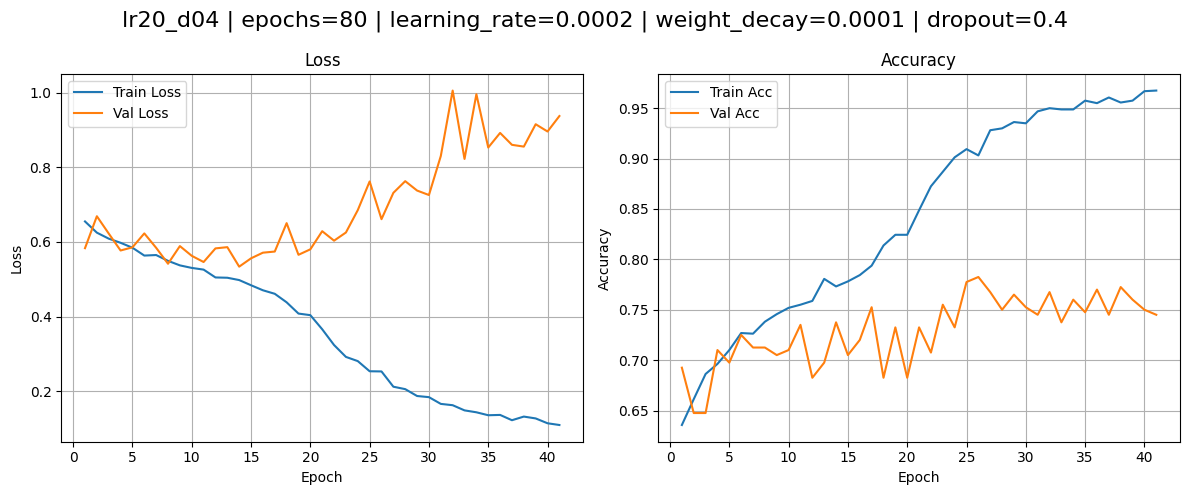

0.7825
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


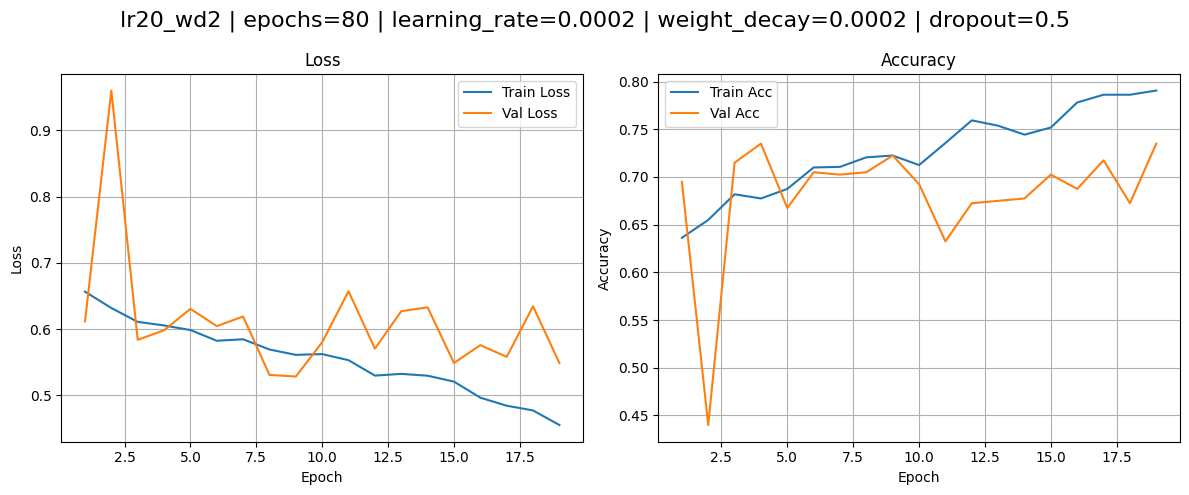

0.735
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0002, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


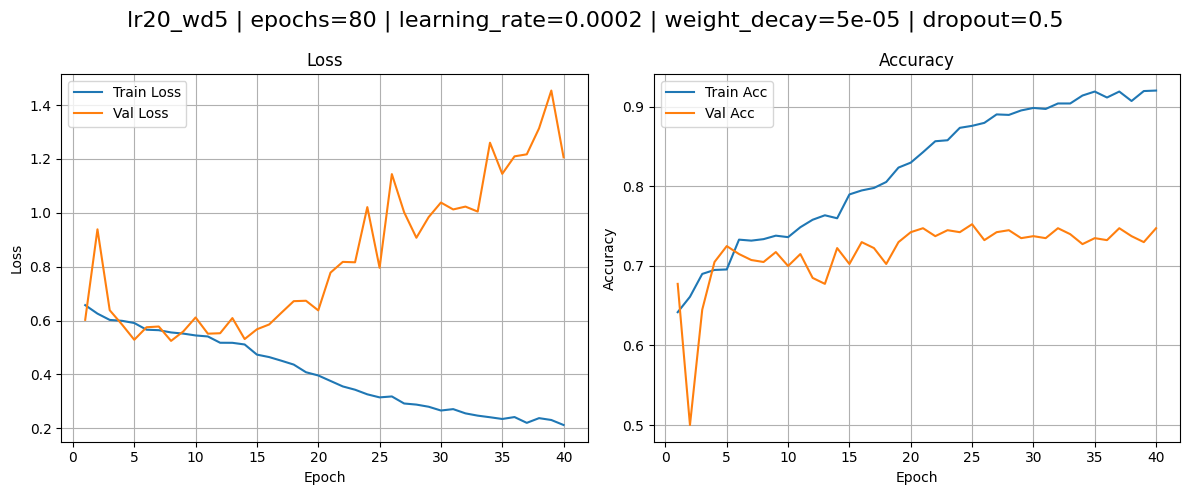

0.7525
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 5e-05, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


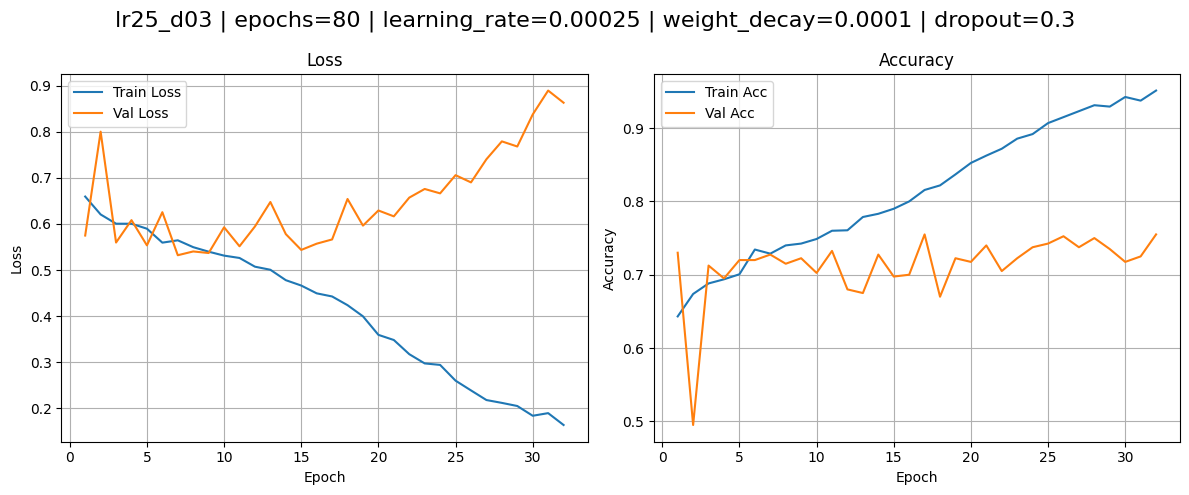

0.755
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00025, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


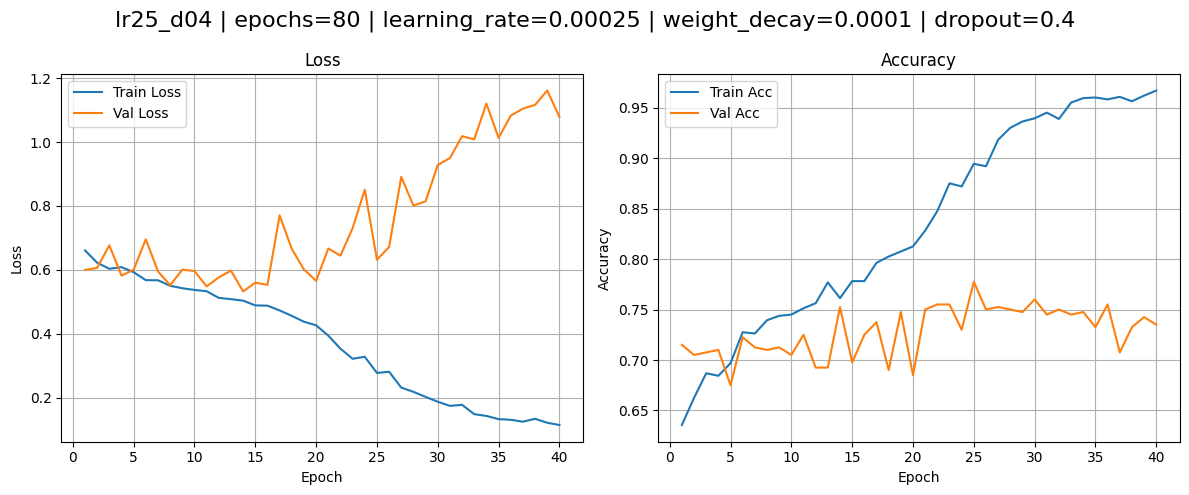

0.7775
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00025, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


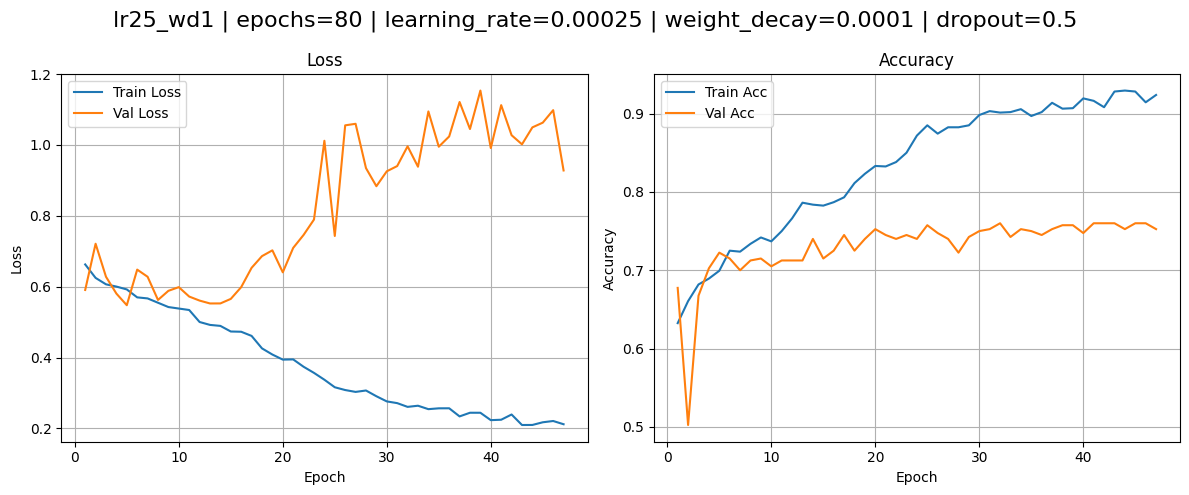

0.76
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00025, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


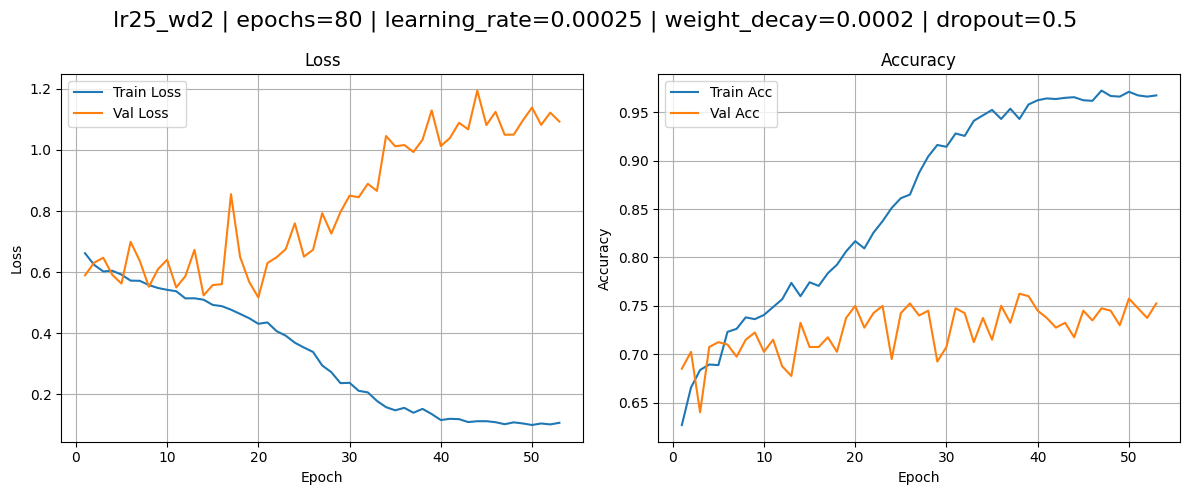

0.7625
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00025, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0002, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


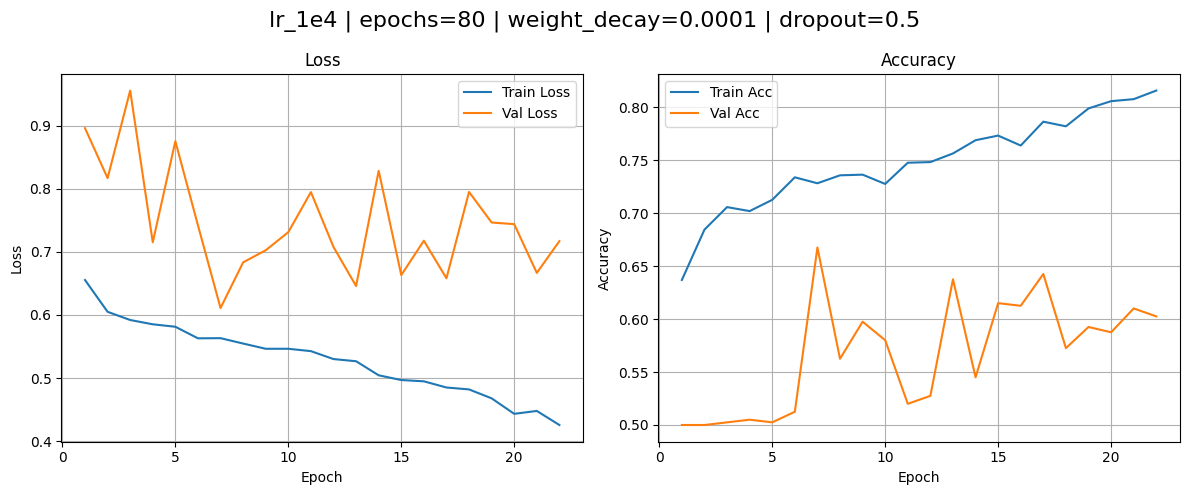

0.6675
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0001, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


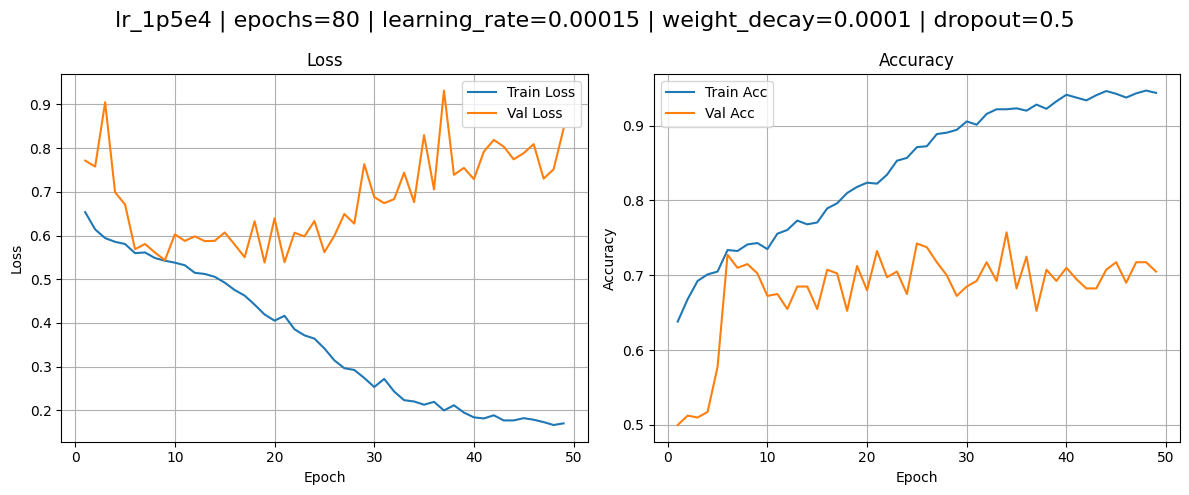

0.7575
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00015, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


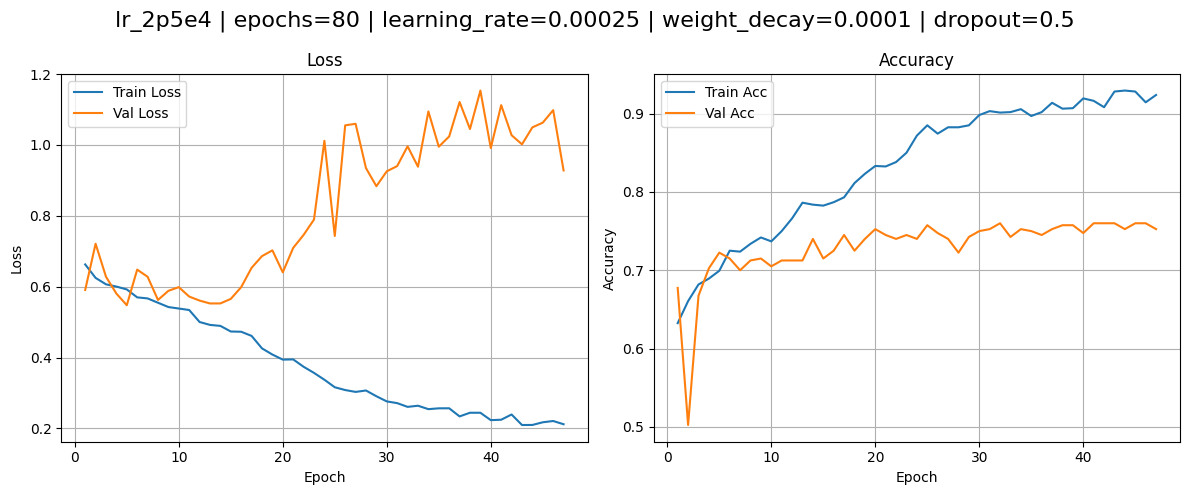

0.76
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00025, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


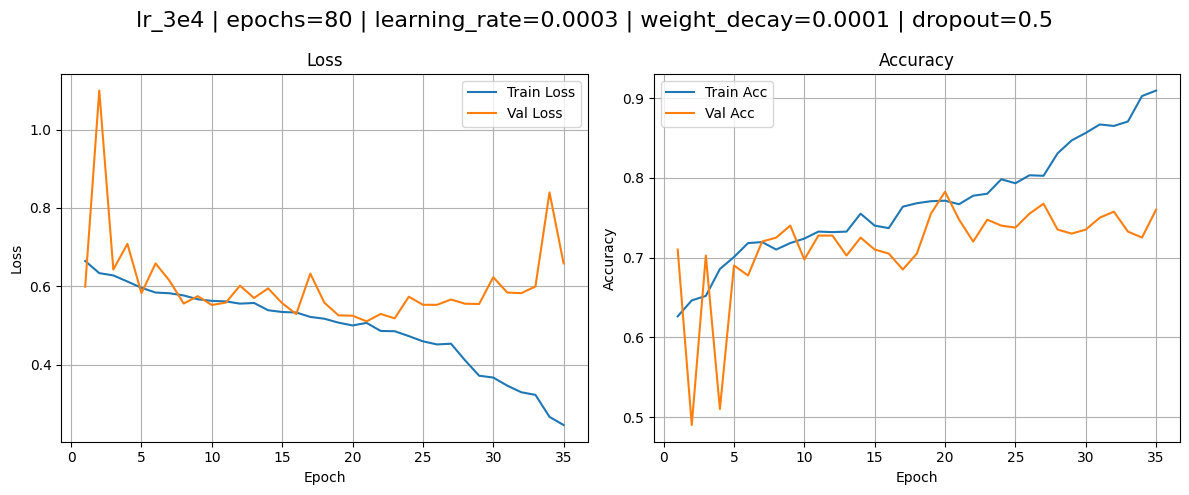

0.7825
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0003, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


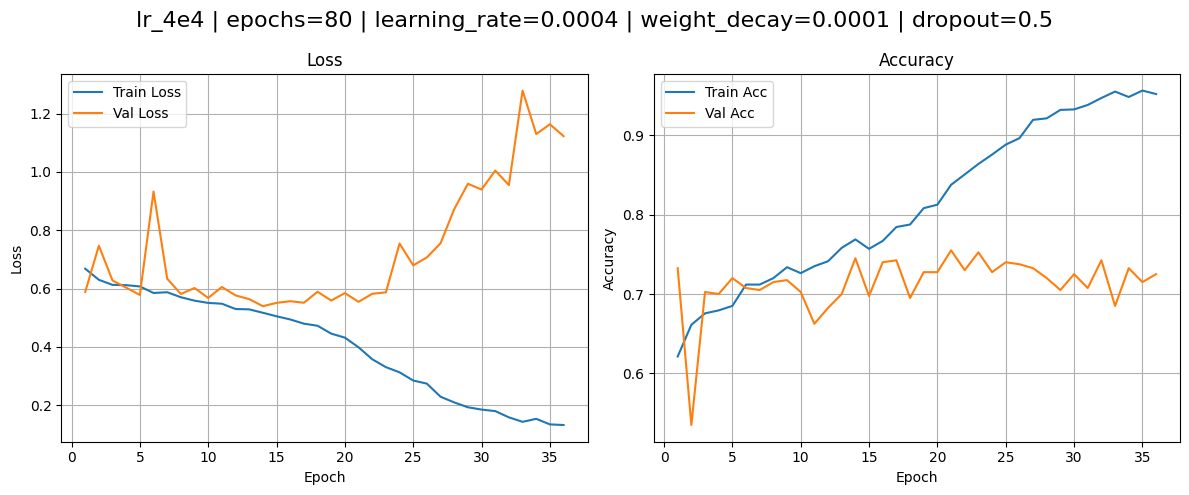

0.755
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0004, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


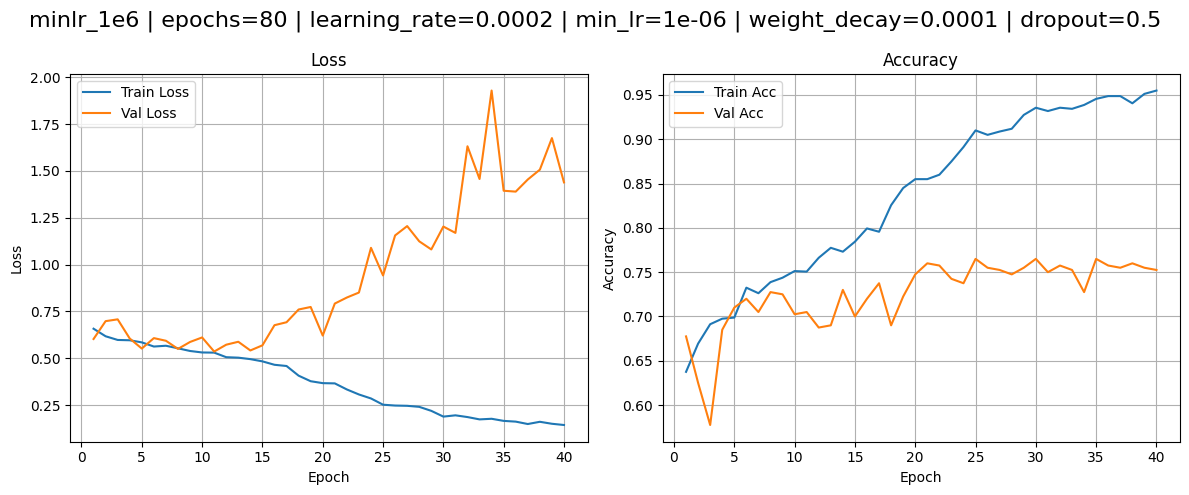

0.765
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


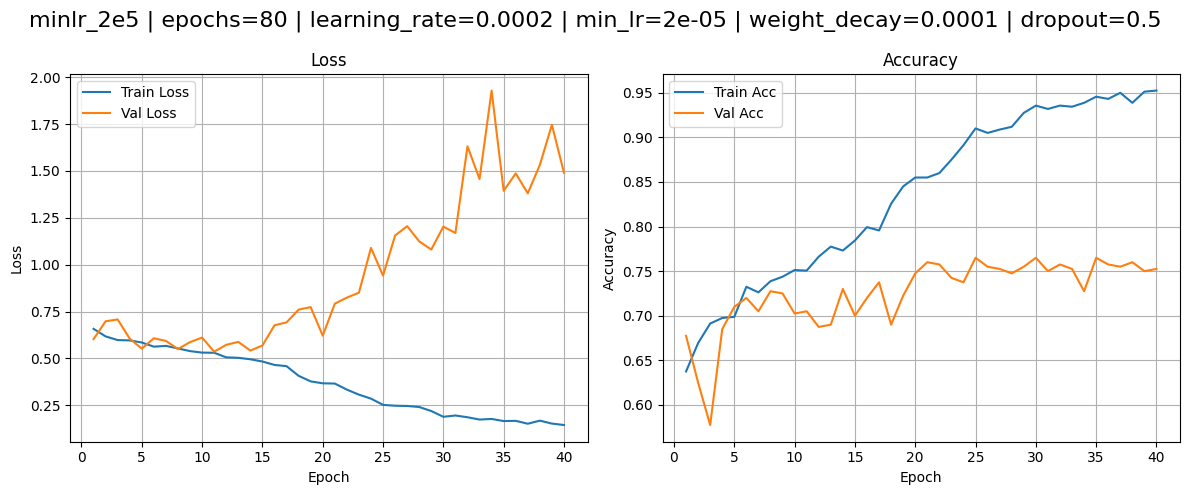

0.765
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 2e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


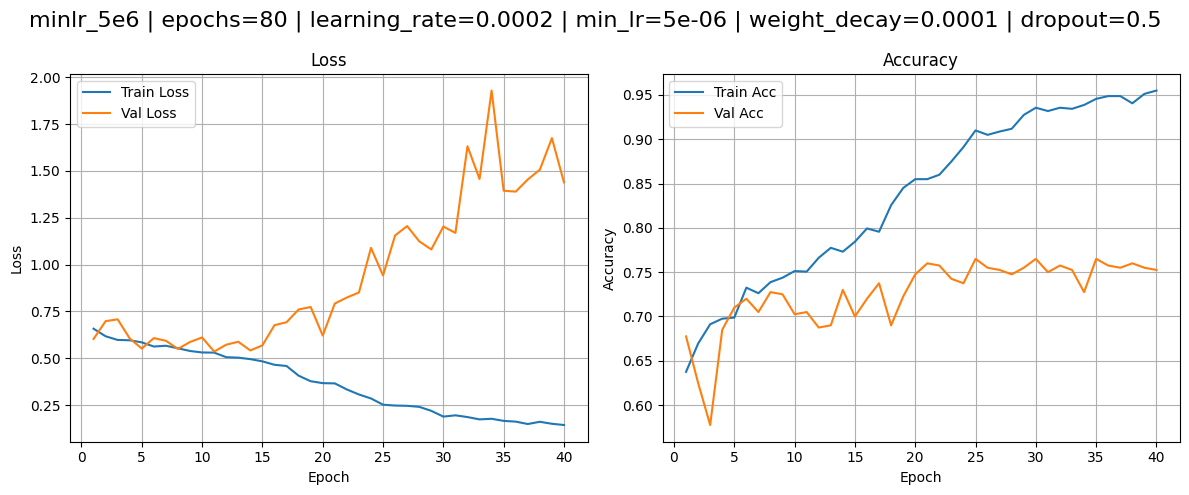

0.765
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 5e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


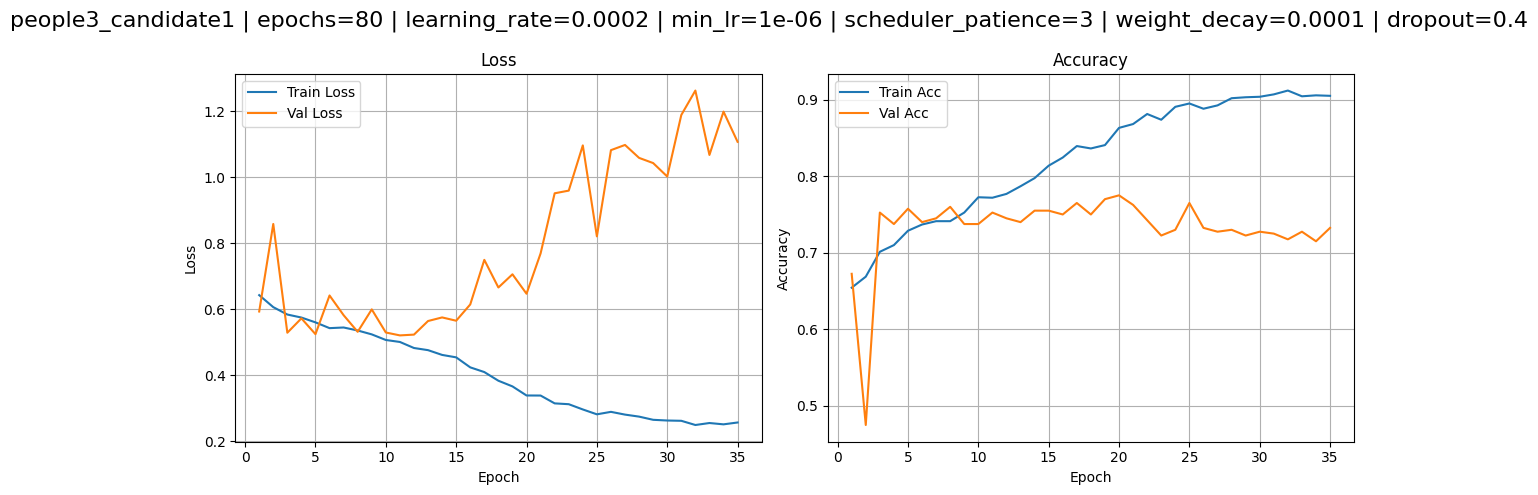

0.775
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 3, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


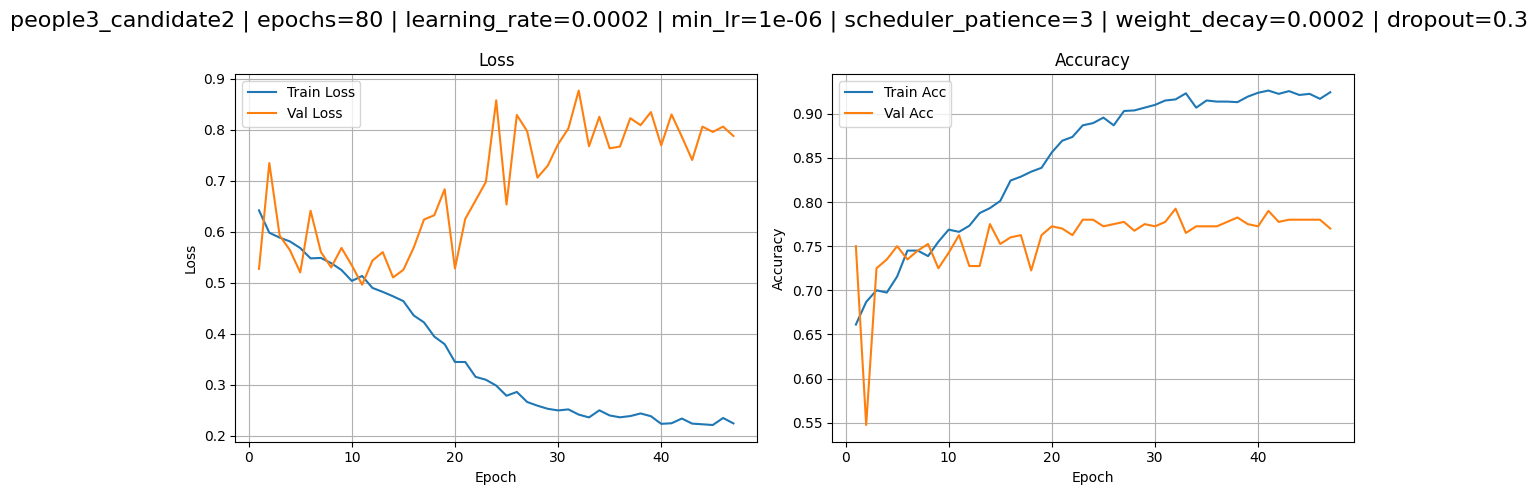

0.7925
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 3, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0002, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


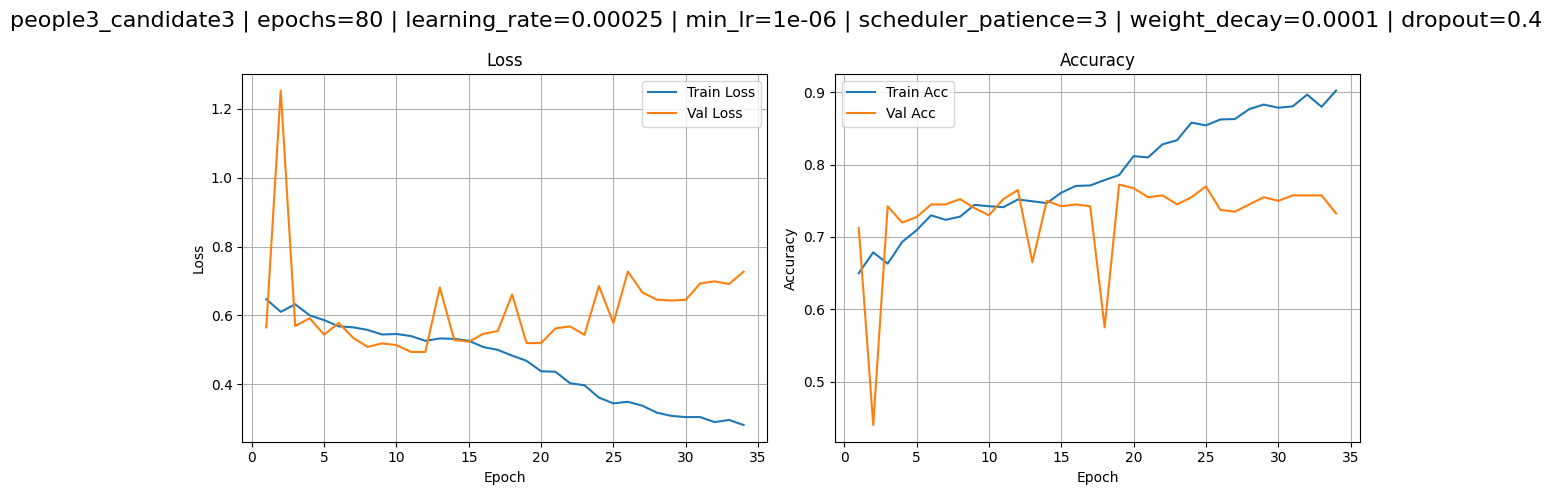

0.7725
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00025, 'min_lr': 1e-06, 'scheduler_patience': 3, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


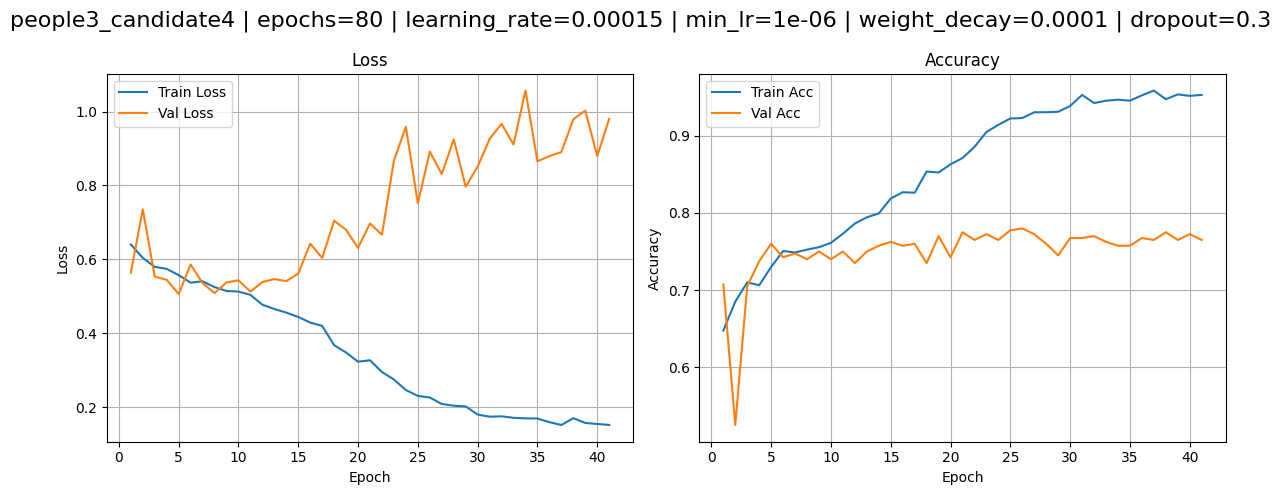

0.78
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00015, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


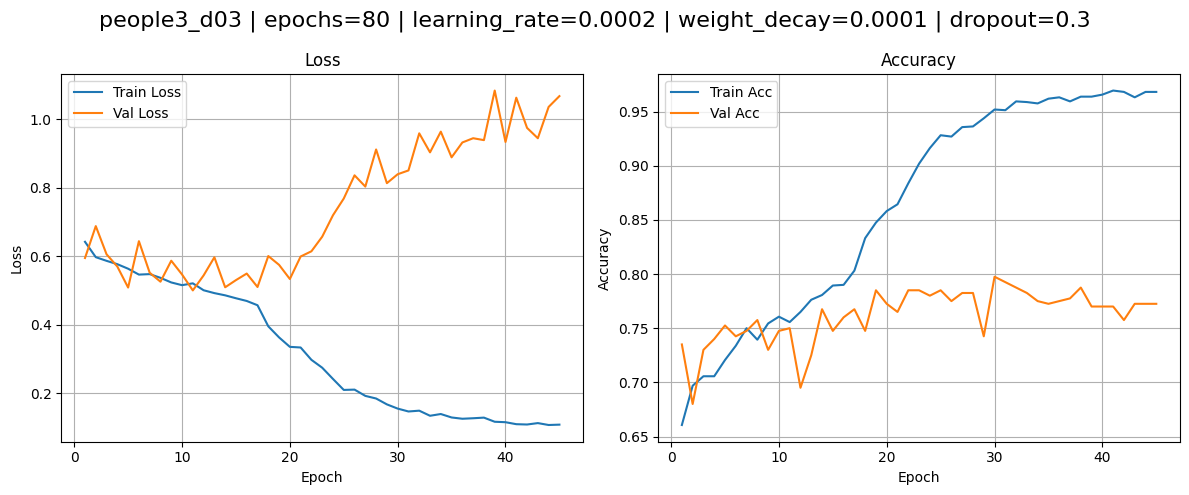

0.7975
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


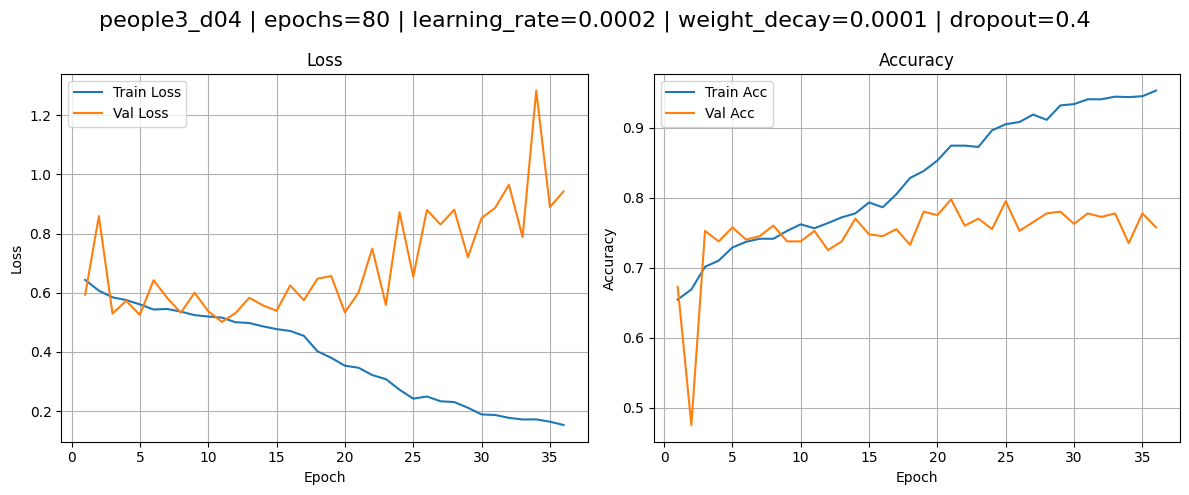

0.7975
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


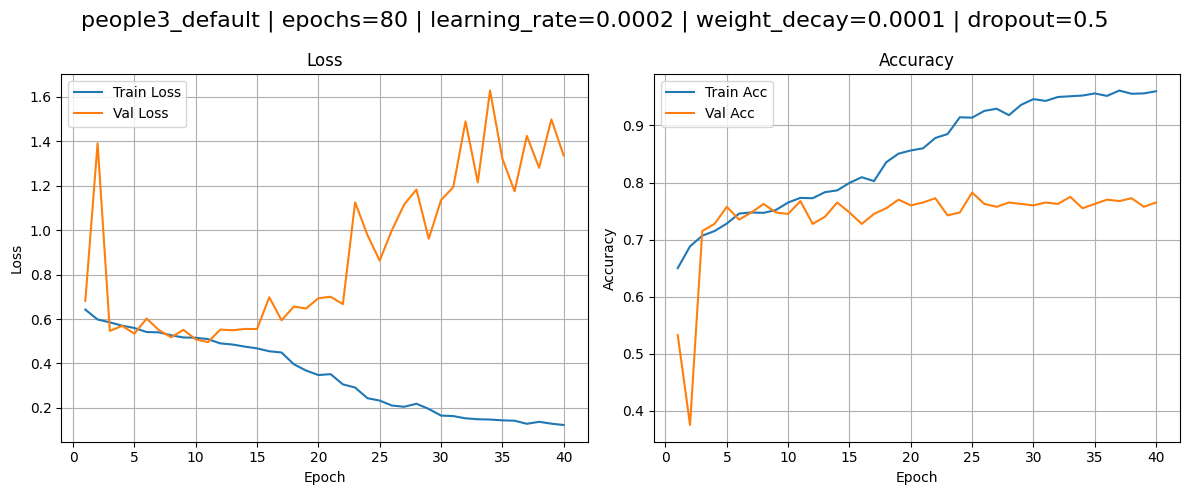

0.7825
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


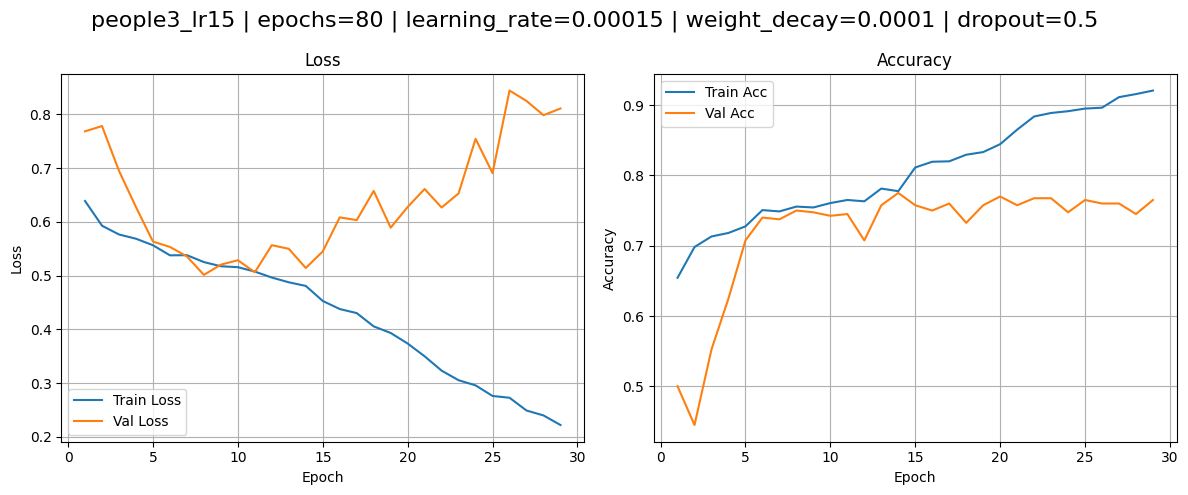

0.775
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00015, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


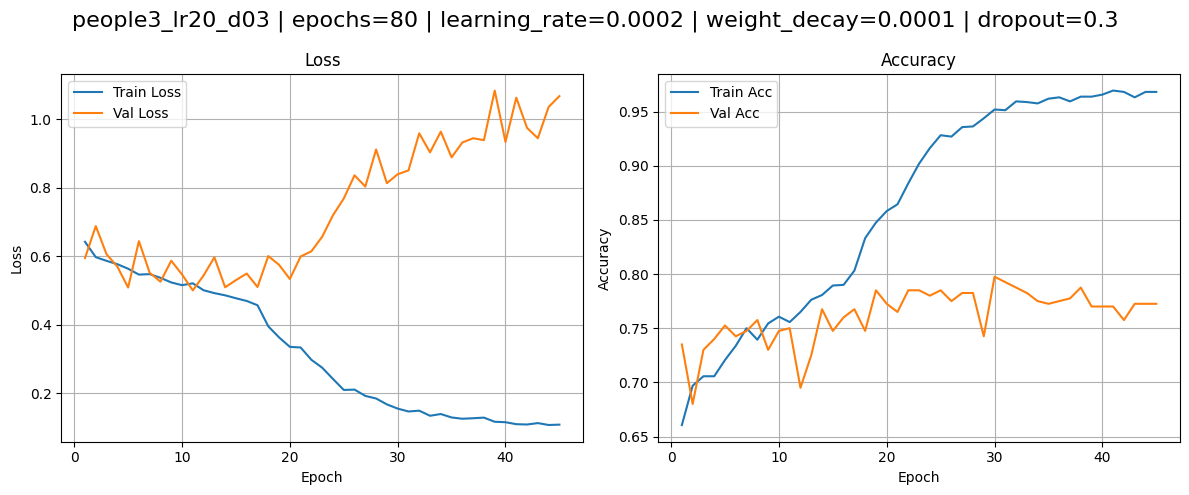

0.7975
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.3, 'edge_importance_weighting': True}


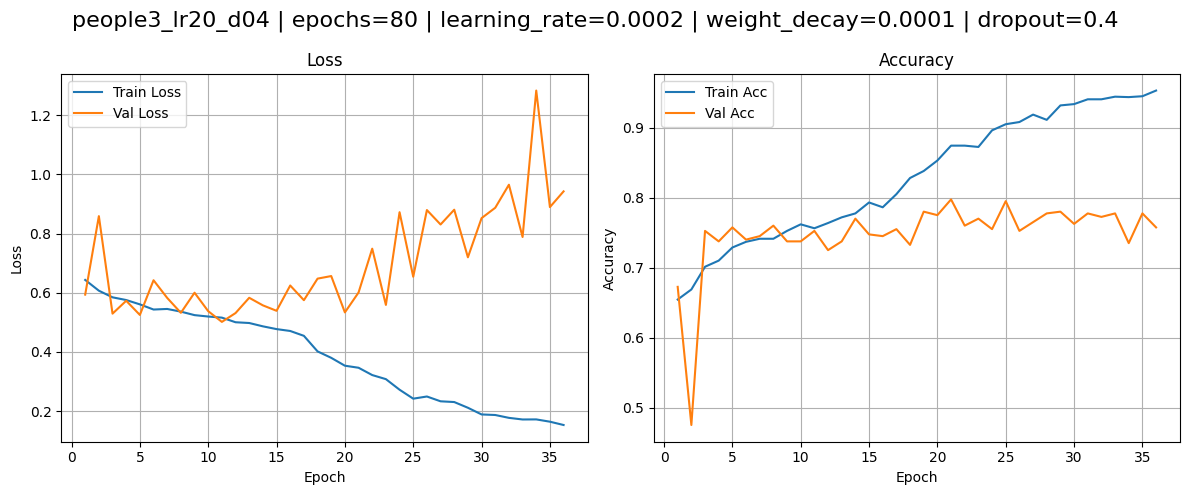

0.7975
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.4, 'edge_importance_weighting': True}


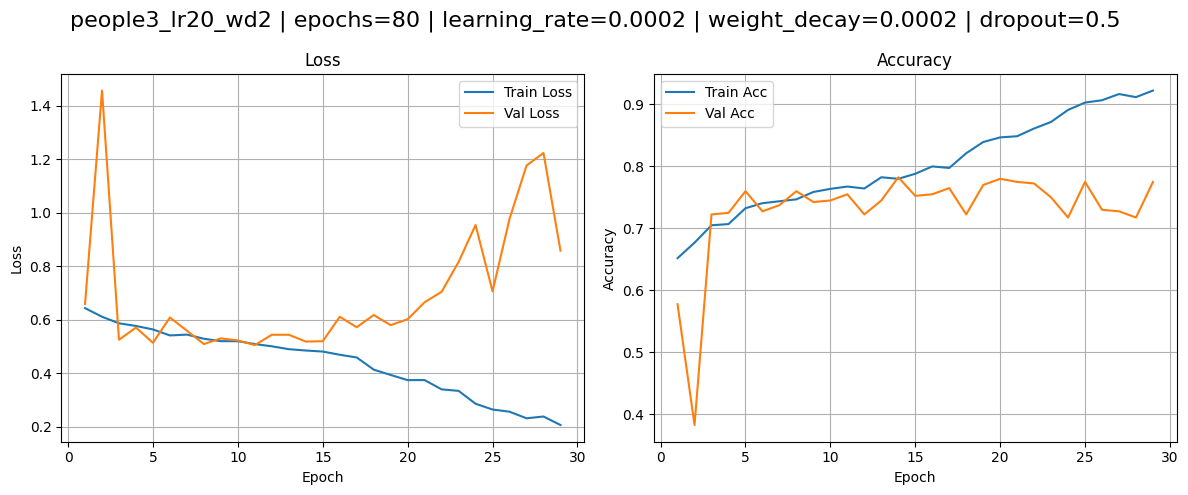

0.7825
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0002, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


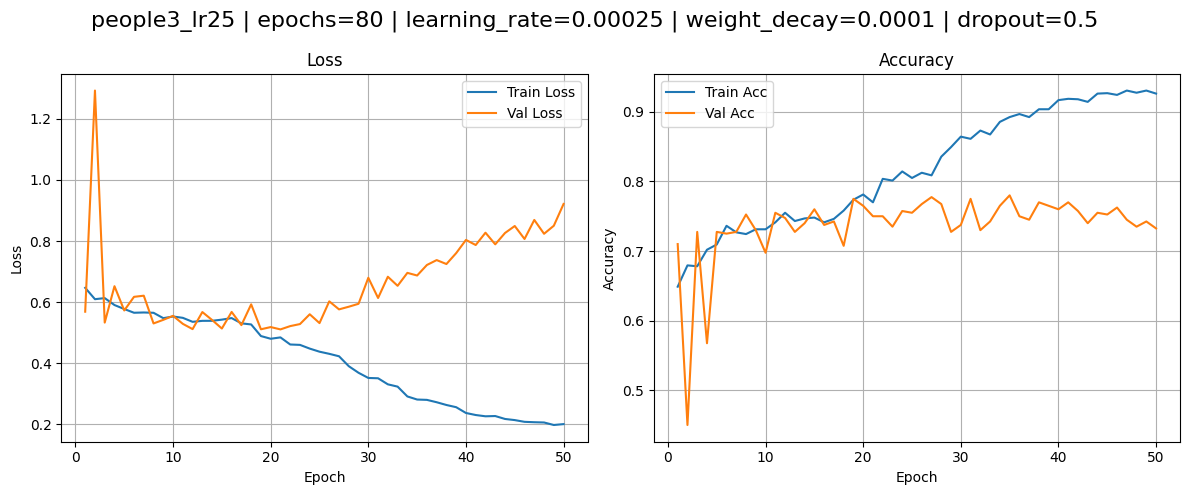

0.78
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.00025, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


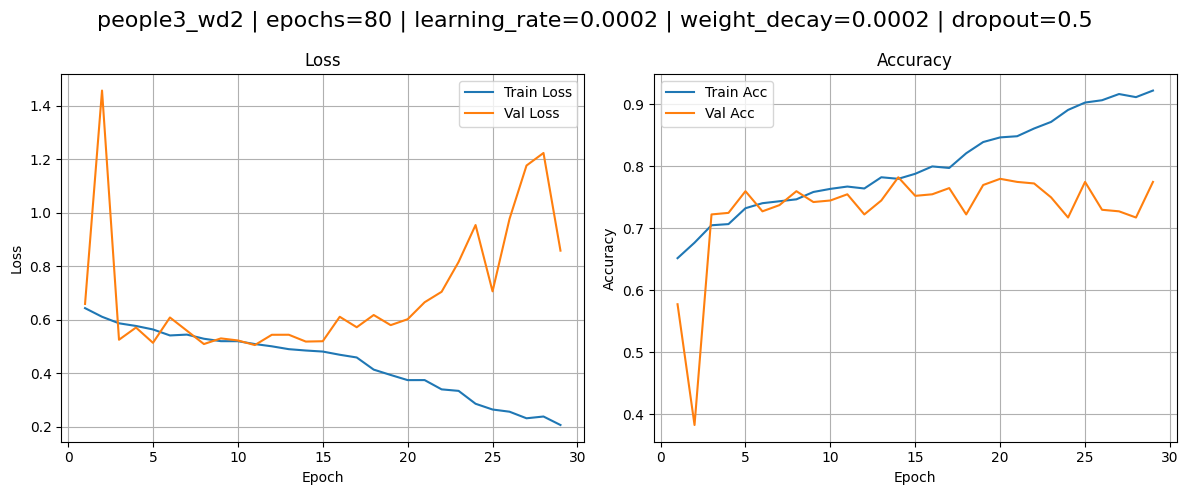

0.7825
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0002, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


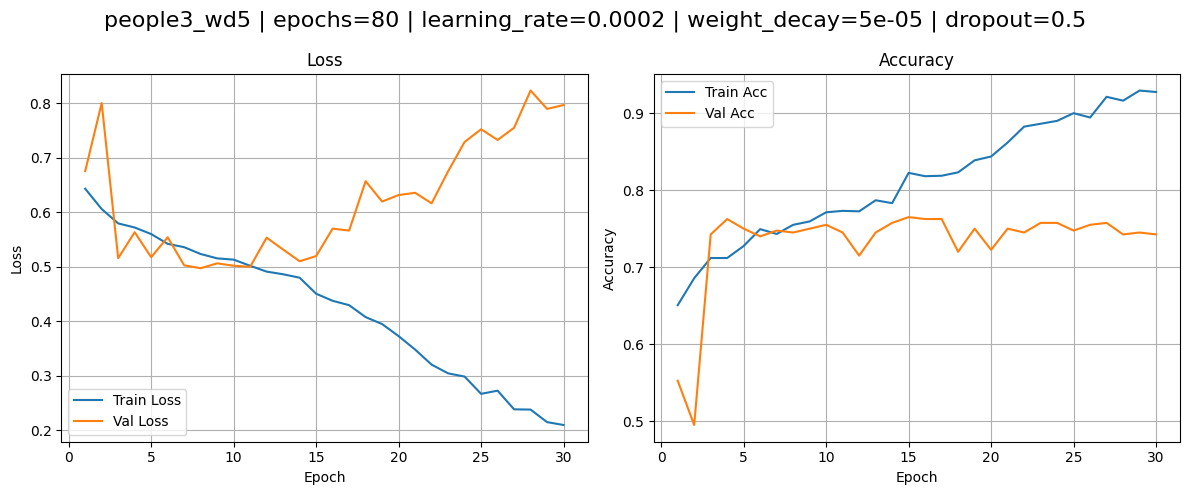

0.765
{'seed': 42, 'max_people': 3, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 5e-05, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


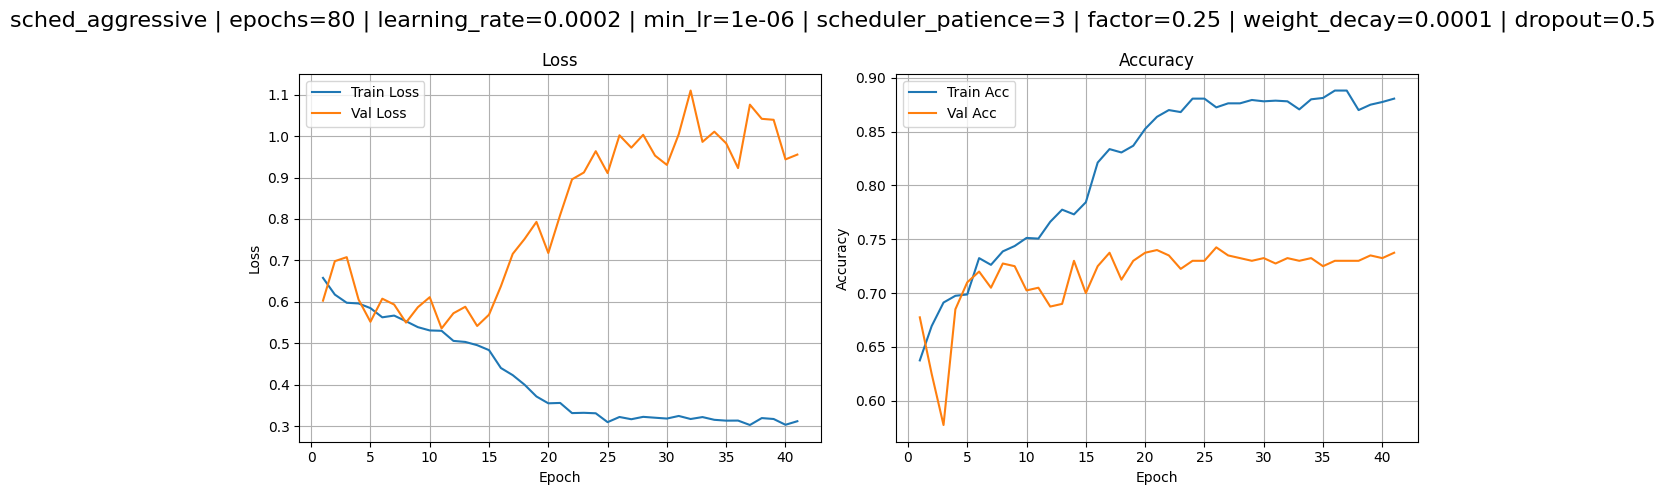

0.7425
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 3, 'factor': 0.25, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


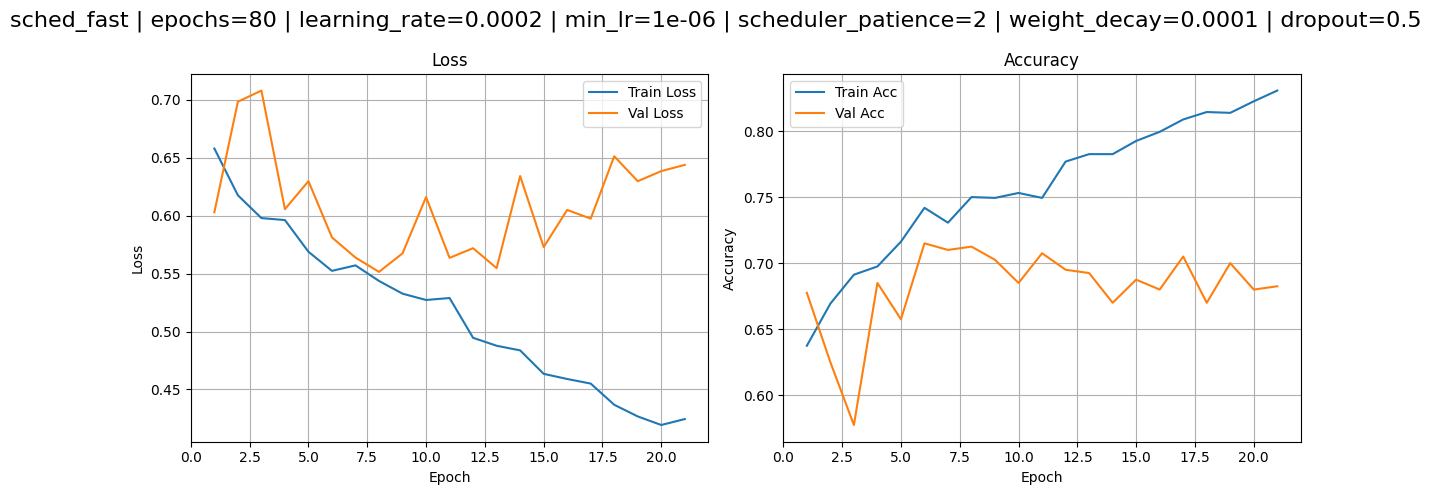

0.715
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 2, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


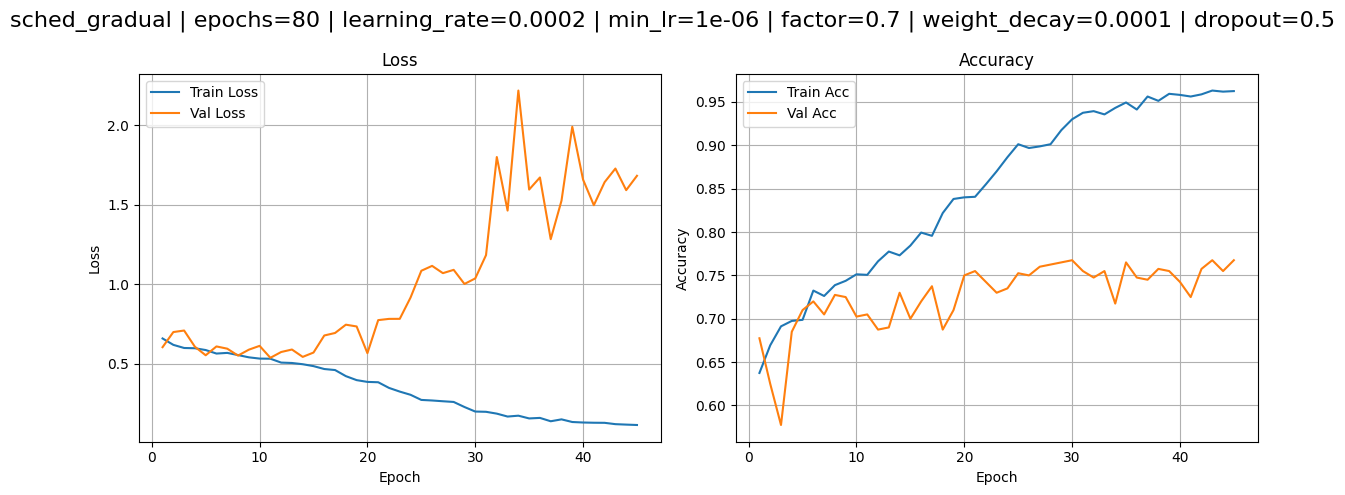

0.7675
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 5, 'factor': 0.7, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


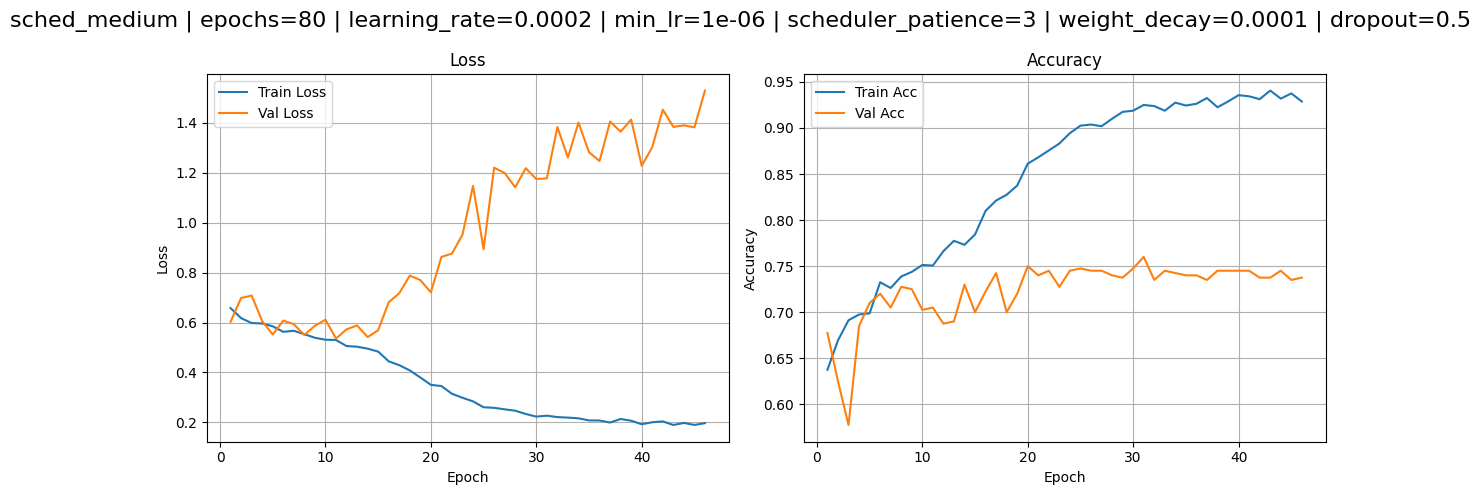

0.76
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-06, 'scheduler_patience': 3, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


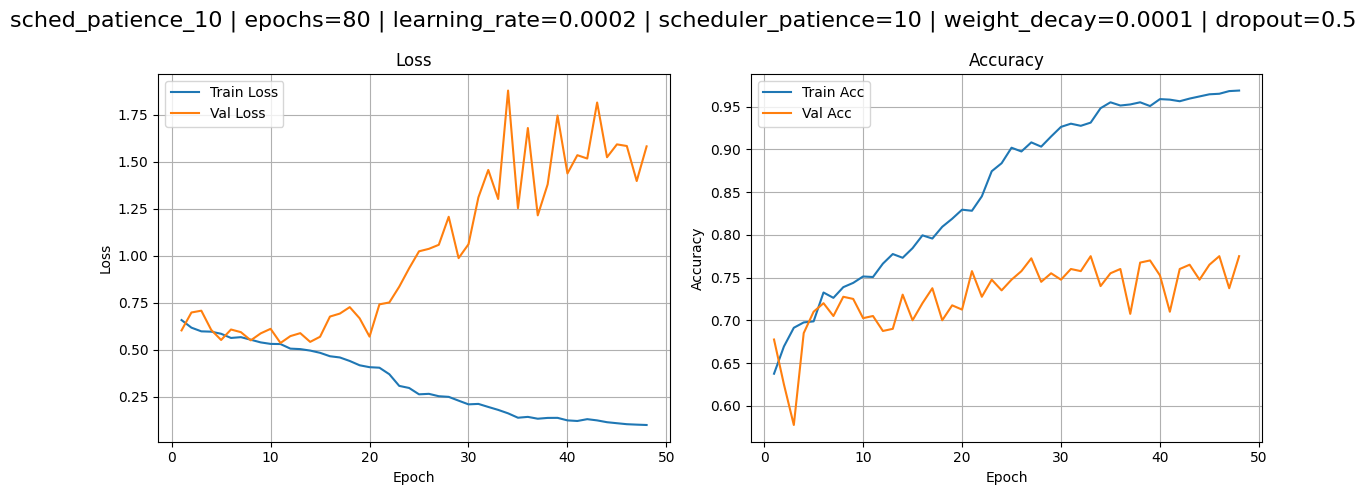

0.775
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 10, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


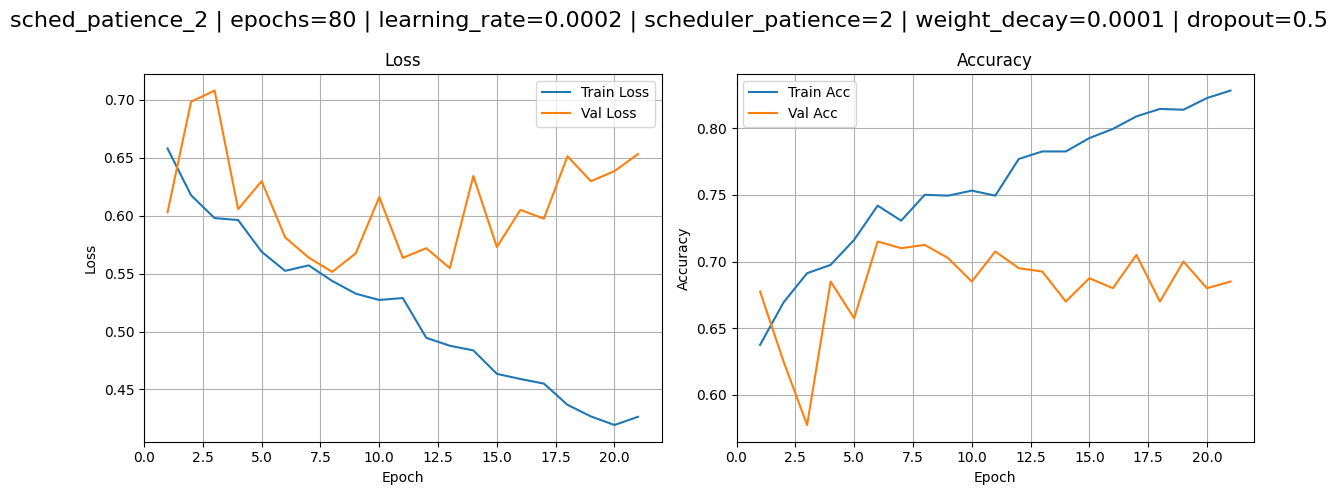

0.715
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 2, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


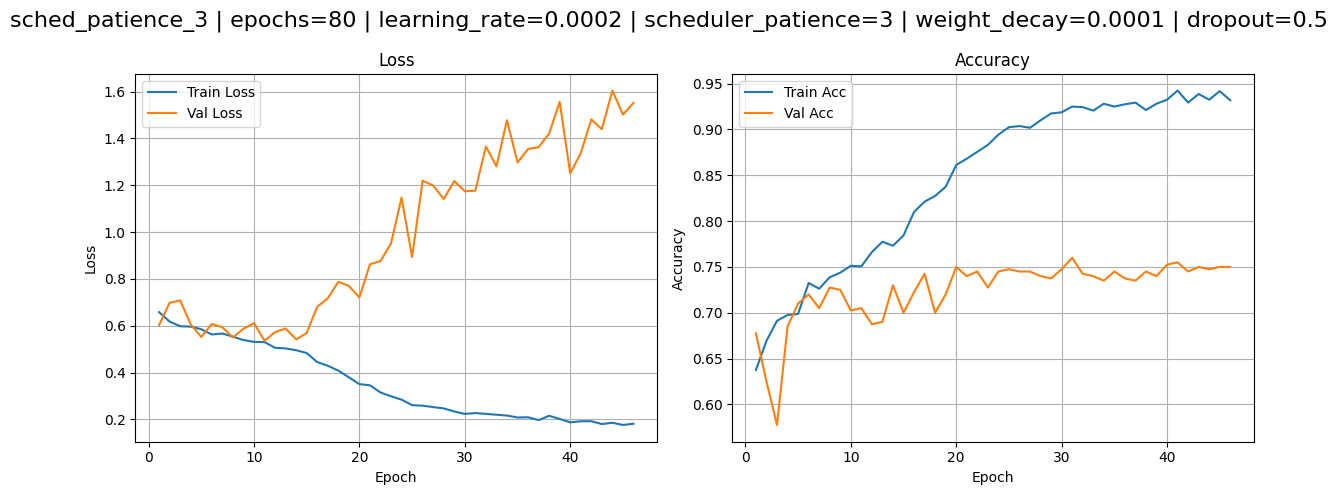

0.76
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 3, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


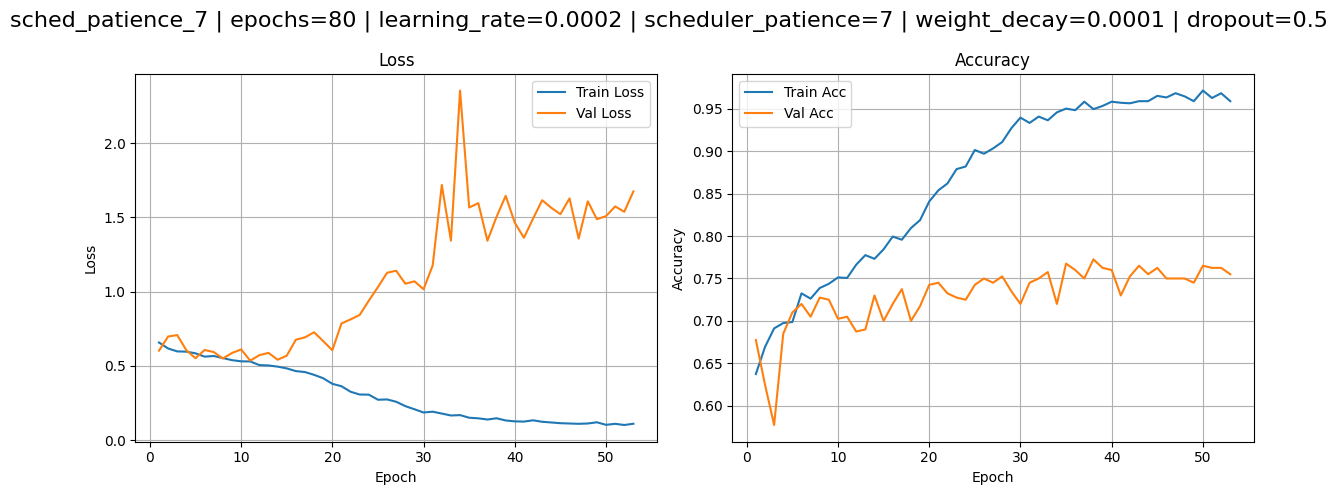

0.7725
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 7, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


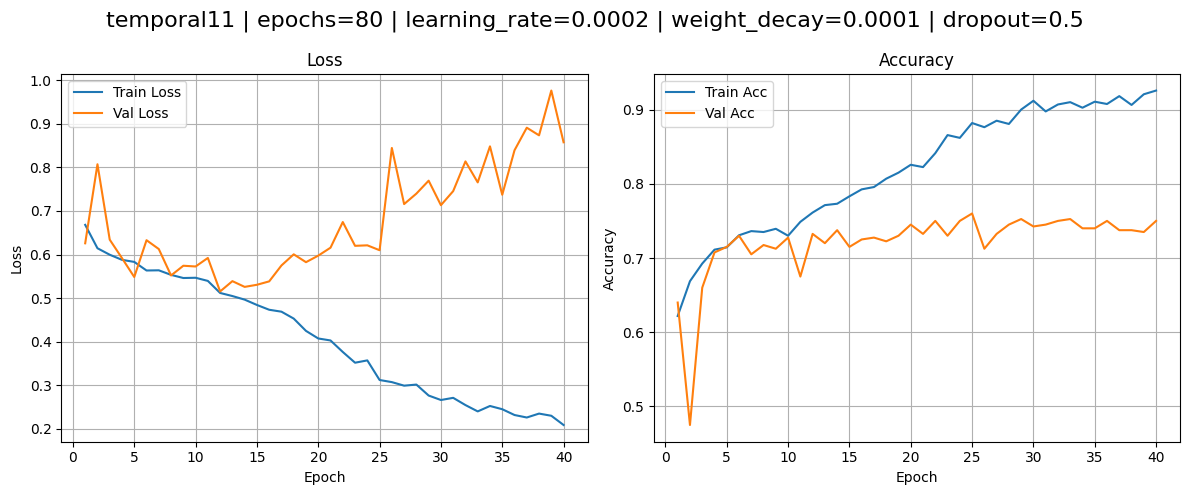

0.76
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 11, 'dropout': 0.5, 'edge_importance_weighting': True}


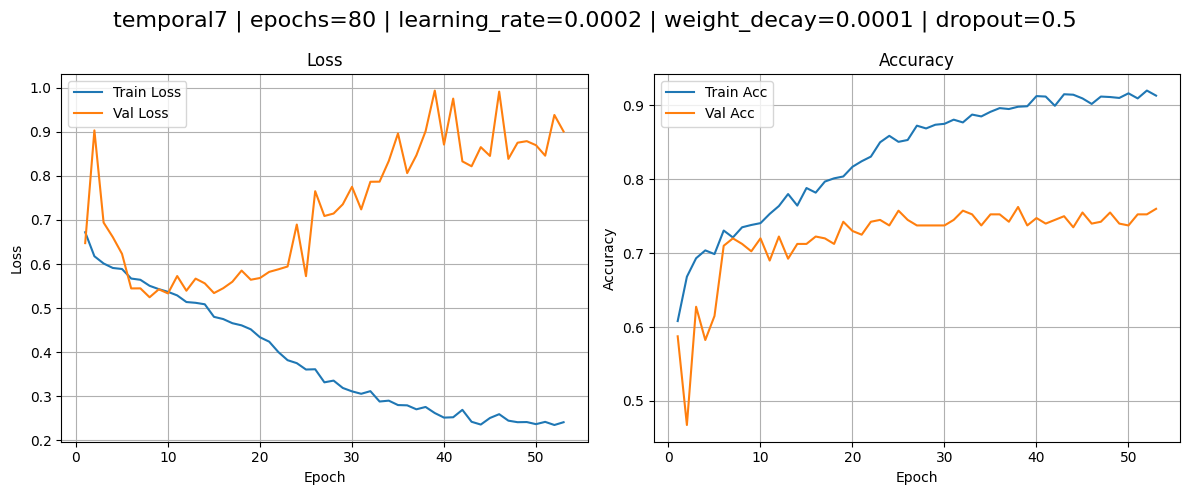

0.7625
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 7, 'dropout': 0.5, 'edge_importance_weighting': True}


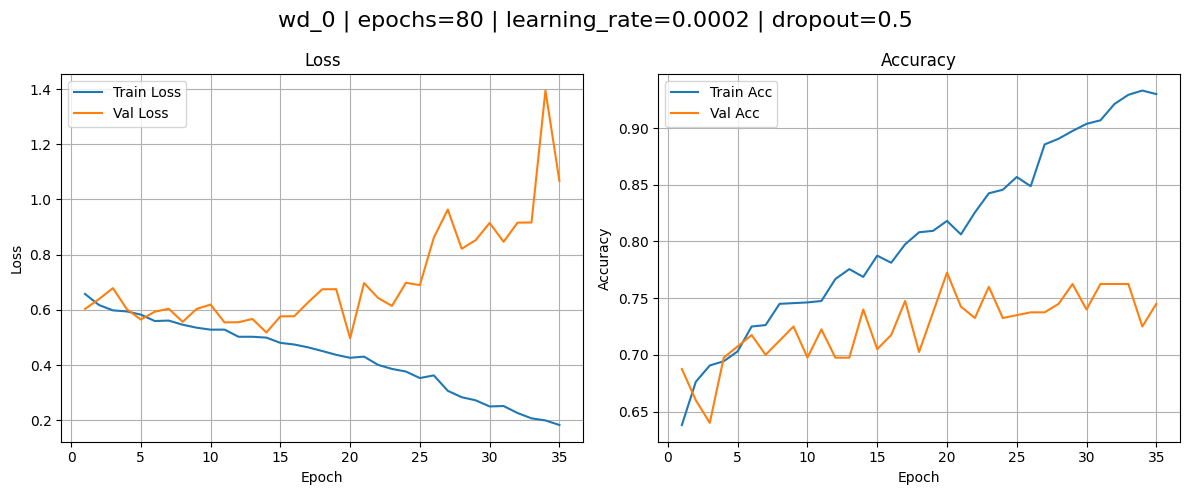

0.7725
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


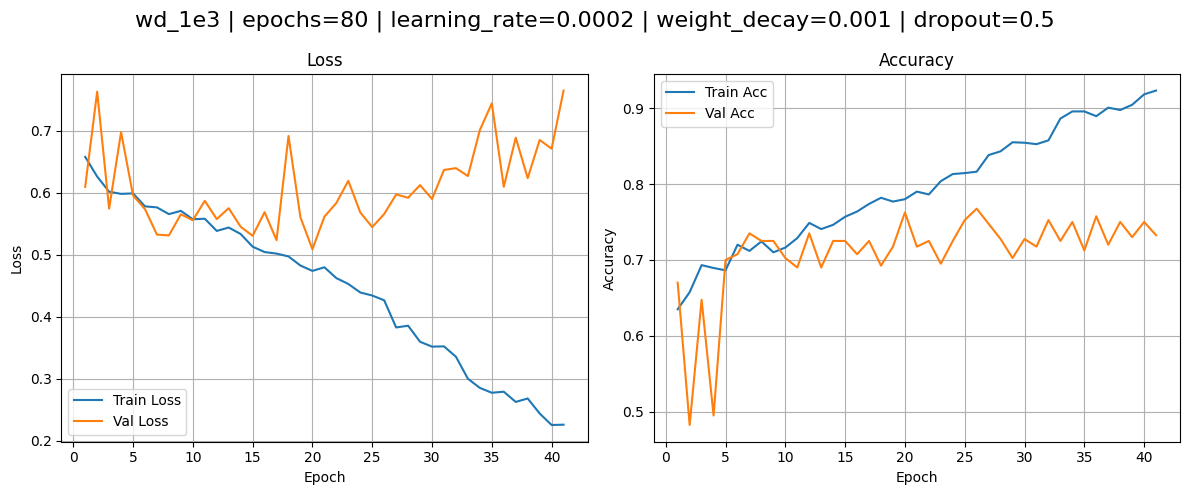

0.7675
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.001, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


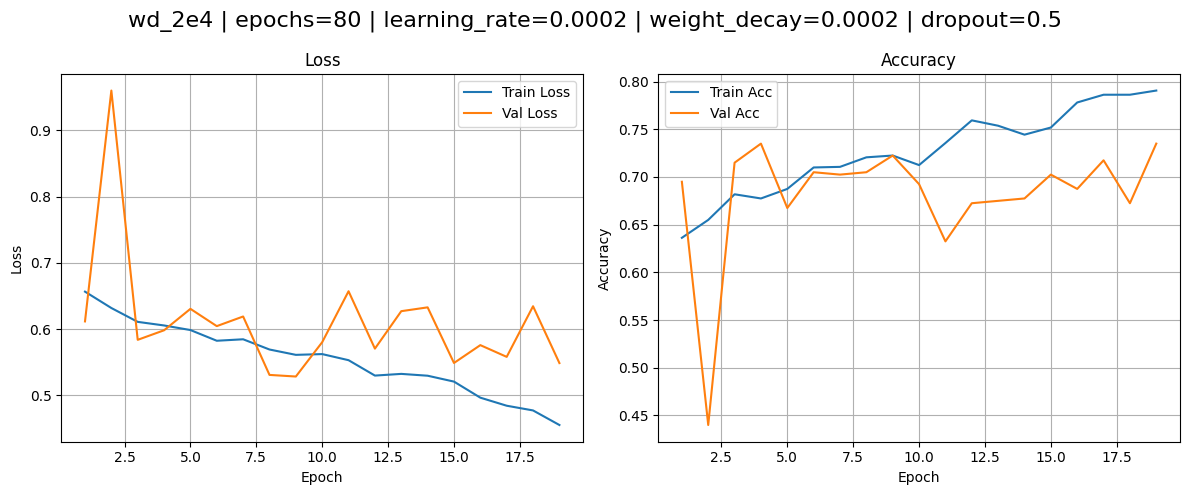

0.735
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0002, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


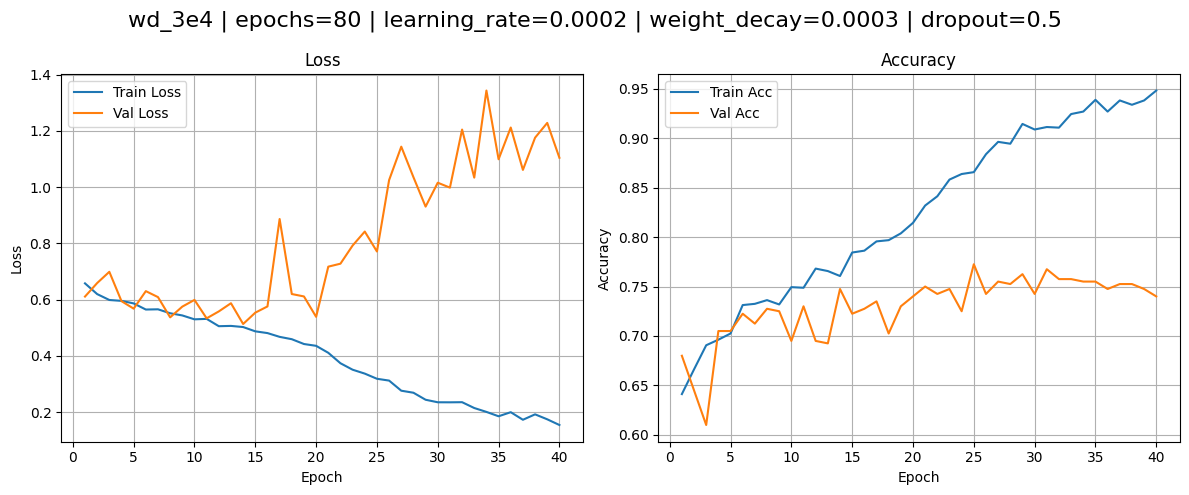

0.7725
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0003, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


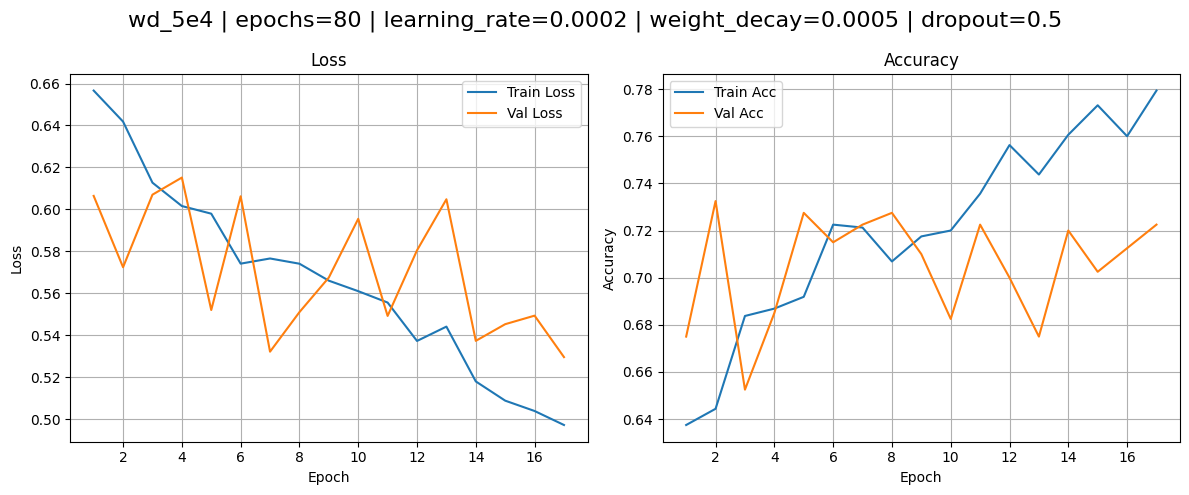

0.7325
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 0.0005, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


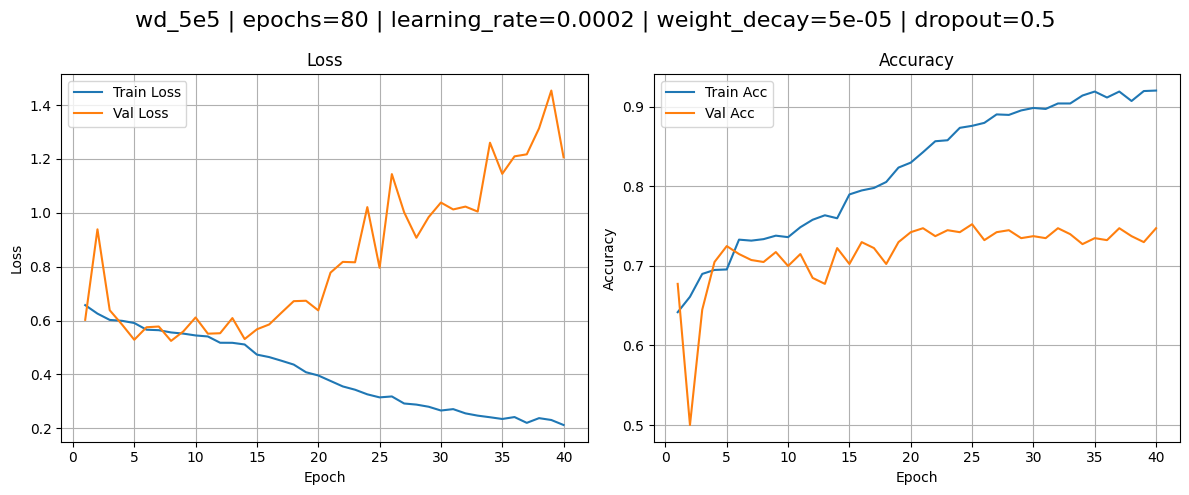

0.7525
{'seed': 42, 'max_people': 2, 'batch_size': 4, 'epochs': 80, 'learning_rate': 0.0002, 'min_lr': 1e-05, 'scheduler_patience': 5, 'factor': 0.5, 'early_stopping_patience': 15, 'amsgrad': False, 'weight_decay': 5e-05, 'adjacency_normalisation_mode': 'column', 'temporal_kernel_size': 9, 'dropout': 0.5, 'edge_importance_weighting': True}


In [5]:

plot_grid_search_results(experiment_root)